# Phase 3 – Exploratory Data Analysis (EDA)

## Objective

Explore both datasets to understand feature distributions, identify relationships between variables, analyze class distributions, and generate visual insights that will guide machine learning model development.

## Step 1: Import Required Libraries

Import all libraries required for data manipulation and visualization.

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings

plt.style.use("default")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

# Create folders for saving plots

os.makedirs("../images/phase3_eda/crop", exist_ok=True)
os.makedirs("../images/phase3_eda/fertilizer", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load Datasets

Load the processed crop training dataset for numerical analysis and the original fertilizer dataset for categorical visualizations. Using the processed data ensures consistency with the machine learning pipeline while preserving readable labels where needed.

In [2]:
# Raw datasets
crop_df = pd.read_csv("../data/raw/crop_recommendation.csv")
fertilizer_df = pd.read_csv("../data/raw/fertilizer_recommendation.csv")

print("Datasets loaded successfully.")

print("\nCrop Dataset Shape :", crop_df.shape)
print("Fertilizer Dataset Shape :", fertilizer_df.shape)

display(crop_df.head())
display(fertilizer_df.head())

Datasets loaded successfully.

Crop Dataset Shape : (2200, 8)
Fertilizer Dataset Shape : (10000, 20)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


## Step 3: Dataset Overview

Display the structure, dimensions, column names, and data types of both datasets to understand their overall composition before performing detailed exploratory analysis.

In [3]:
print("Crop Dataset Shape :", crop_df.shape)
print("Fertilizer Dataset Shape :", fertilizer_df.shape)

print("\n")

display(crop_df.head())

display(fertilizer_df.head())

Crop Dataset Shape : (2200, 8)
Fertilizer Dataset Shape : (10000, 20)




,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


# Step 3 – Dataset Overview

Understand the structure of both datasets by examining their dimensions, data types, and overall information. This provides an overview of the available features before performing statistical analysis and visualization.

In [4]:
print("=" * 60)
print("Crop Dataset Information")
print("=" * 60)

crop_df.info()

print("\n")

print("=" * 60)
print("Fertilizer Dataset Information")
print("=" * 60)

fertilizer_df.info()

Crop Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


Fertilizer Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Soil_Type                    10000 non-null  object 
 1   Soil_pH                      10000 non-null  float64
 2   Soil_Mo

# Step 4 – Summary Statistics

Generate descriptive statistics to understand the distribution of numerical features within both datasets.

In [5]:
print("=" * 60)
print("Crop Dataset Summary Statistics")
print("=" * 60)

display(crop_df.describe())

print("\n")

print("=" * 60)
print("Fertilizer Dataset Summary Statistics")
print("=" * 60)

display(fertilizer_df.describe(include="all"))

Crop Dataset Summary Statistics


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117




Fertilizer Dataset Summary Statistics


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000,10000,10000,10000,10000.000000,10000.000000,10000
unique,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,4,3,4,7,5,NaN,NaN,7
top,Sandy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wheat,Harvest,Kharif,Sprinkler,Cotton,West,NaN,NaN,Urea
freq,2536,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1467,2547,3363,2531,1492,2026,NaN,NaN,3101
mean,NaN,6.485728,35.411531,0.844731,1.543156,88.995000,48.965100,64.147000,25.058906,60.093727,1588.085798,NaN,NaN,NaN,NaN,NaN,NaN,176.165508,4.531666,NaN
std,NaN,1.152964,14.413002,0.372406,0.839514,40.336674,23.195588,31.867211,8.601550,17.386120,810.992404,NaN,NaN,NaN,NaN,NaN,NaN,72.235790,2.013522,NaN
min,NaN,4.500000,10.000000,0.200000,0.100000,20.000000,10.000000,10.000000,10.000000,30.010000,200.080000,NaN,NaN,NaN,NaN,NaN,NaN,50.010000,1.000000,NaN
25%,NaN,5.490000,23.030000,0.520000,0.820000,54.000000,29.000000,37.000000,17.580000,44.925000,874.780000,NaN,NaN,NaN,NaN,NaN,NaN,113.175000,2.780000,NaN
50%,NaN,6.460000,35.645000,0.850000,1.530000,89.000000,49.000000,64.000000,25.085000,60.345000,1594.295000,NaN,NaN,NaN,NaN,NaN,NaN,176.835000,4.550000,NaN
75%,NaN,7.490000,47.662500,1.160000,2.270000,124.000000,69.000000,92.000000,32.502500,75.420000,2283.782500,NaN,NaN,NaN,NaN,NaN,NaN,239.232500,6.260000,NaN


# Step 5 – Distribution of Crop Features

Visualize the distribution of every numerical feature in the Crop Recommendation dataset.

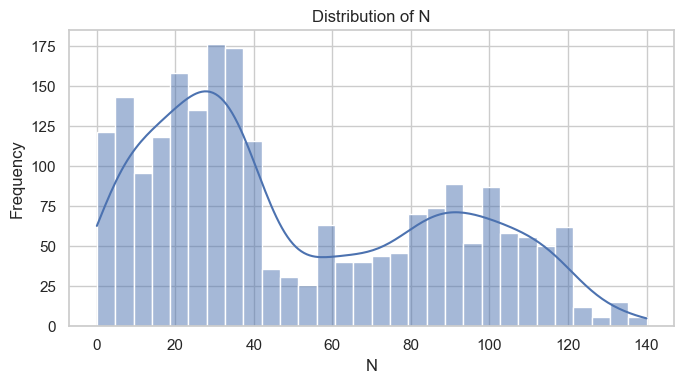

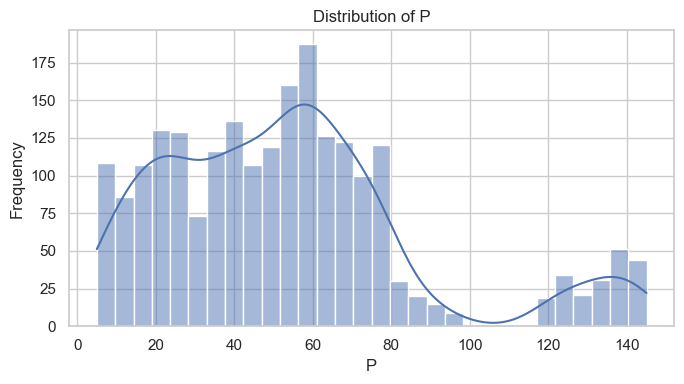

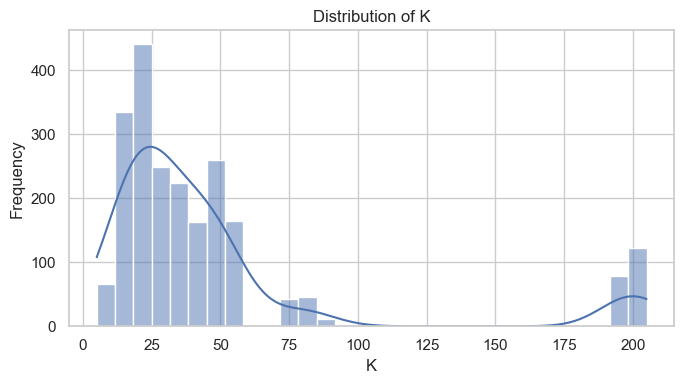

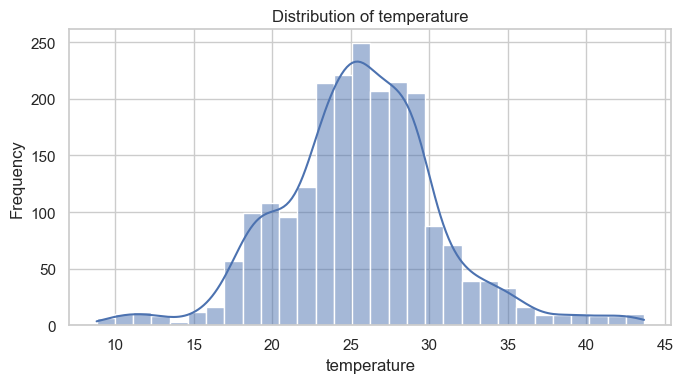

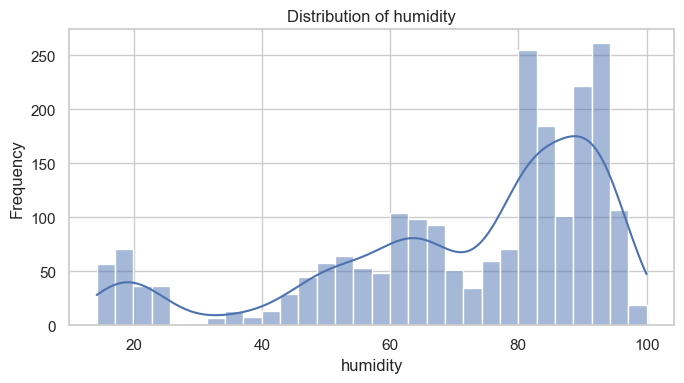

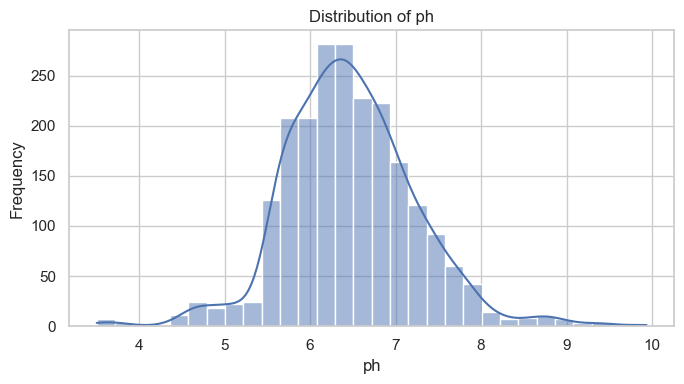

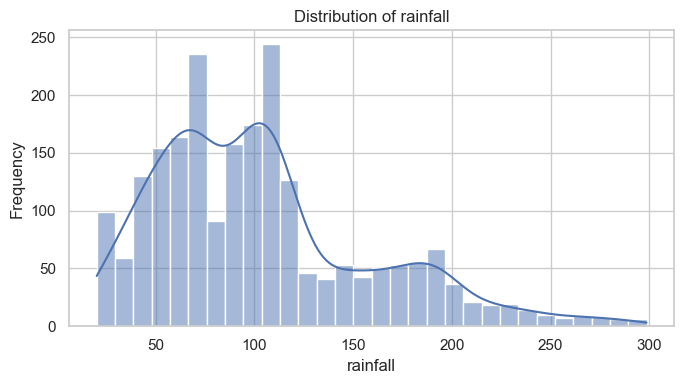

In [6]:
crop_numeric = crop_df.select_dtypes(include=["int64", "float64"]).columns

for column in crop_numeric:
    plt.figure(figsize=(7,4))

    sns.histplot(
        crop_df[column],
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(f"../images/eda/crop_hist_{column}.png")

    plt.show()

## 📖 Interpretation

- The crop dataset contains **2,200 observations** with **7 numerical features** representing soil nutrients and environmental conditions.
- Overall, the feature distributions indicate a diverse range of agricultural conditions suitable for multiple crop types.

### Nitrogen (N)
- Nitrogen values range from **0 to 140**.
- The distribution is **multimodal**, indicating that different crops require varying nitrogen levels.
- Most observations are concentrated between **10 and 40**, while a smaller group requires higher nitrogen levels.

### Phosphorus (P)
- Phosphorus values range from **5 to 145**.
- The distribution is slightly skewed with multiple peaks.
- Most values lie between **20 and 80**, with relatively few observations above **120**.

### Potassium (K)
- Potassium exhibits a **highly right-skewed** distribution.
- Most samples have potassium levels between **10 and 60**.
- A distinct cluster around **190–205** suggests that certain crops require significantly higher potassium concentrations.

### Temperature
- Temperature values range approximately from **9°C to 44°C**.
- The distribution is close to **normal (bell-shaped)**.
- Most crops are grown under temperatures between **20°C and 30°C**.

### Humidity
- Humidity values range from approximately **14% to 100%**.
- Most observations are concentrated between **75% and 95%**.
- This indicates that many crops in the dataset prefer relatively humid growing conditions.

### Soil pH
- Soil pH ranges from approximately **3.5 to 10**.
- The majority of observations fall between **6.0 and 7.0**, indicating slightly acidic to neutral soils.
- Extreme pH values are relatively uncommon.

### Rainfall
- Rainfall ranges from approximately **20 mm to 300 mm**.
- The distribution is **positively skewed**, with most observations between **50 mm and 120 mm**.
- Only a small number of crops require very high rainfall.

### Overall Observation
- The dataset contains diverse nutrient and environmental conditions corresponding to different crop types.
- The presence of multimodal distributions suggests that feature values vary considerably across crop classes, making these variables informative for the crop recommendation model.

# Step 6 – Crop Dataset Boxplots

## 🎯 Objective

Visualize the distribution and spread of each numerical feature using boxplots. This helps identify the presence of outliers, understand feature variability, and determine whether any unusual values exist that may influence model performance.

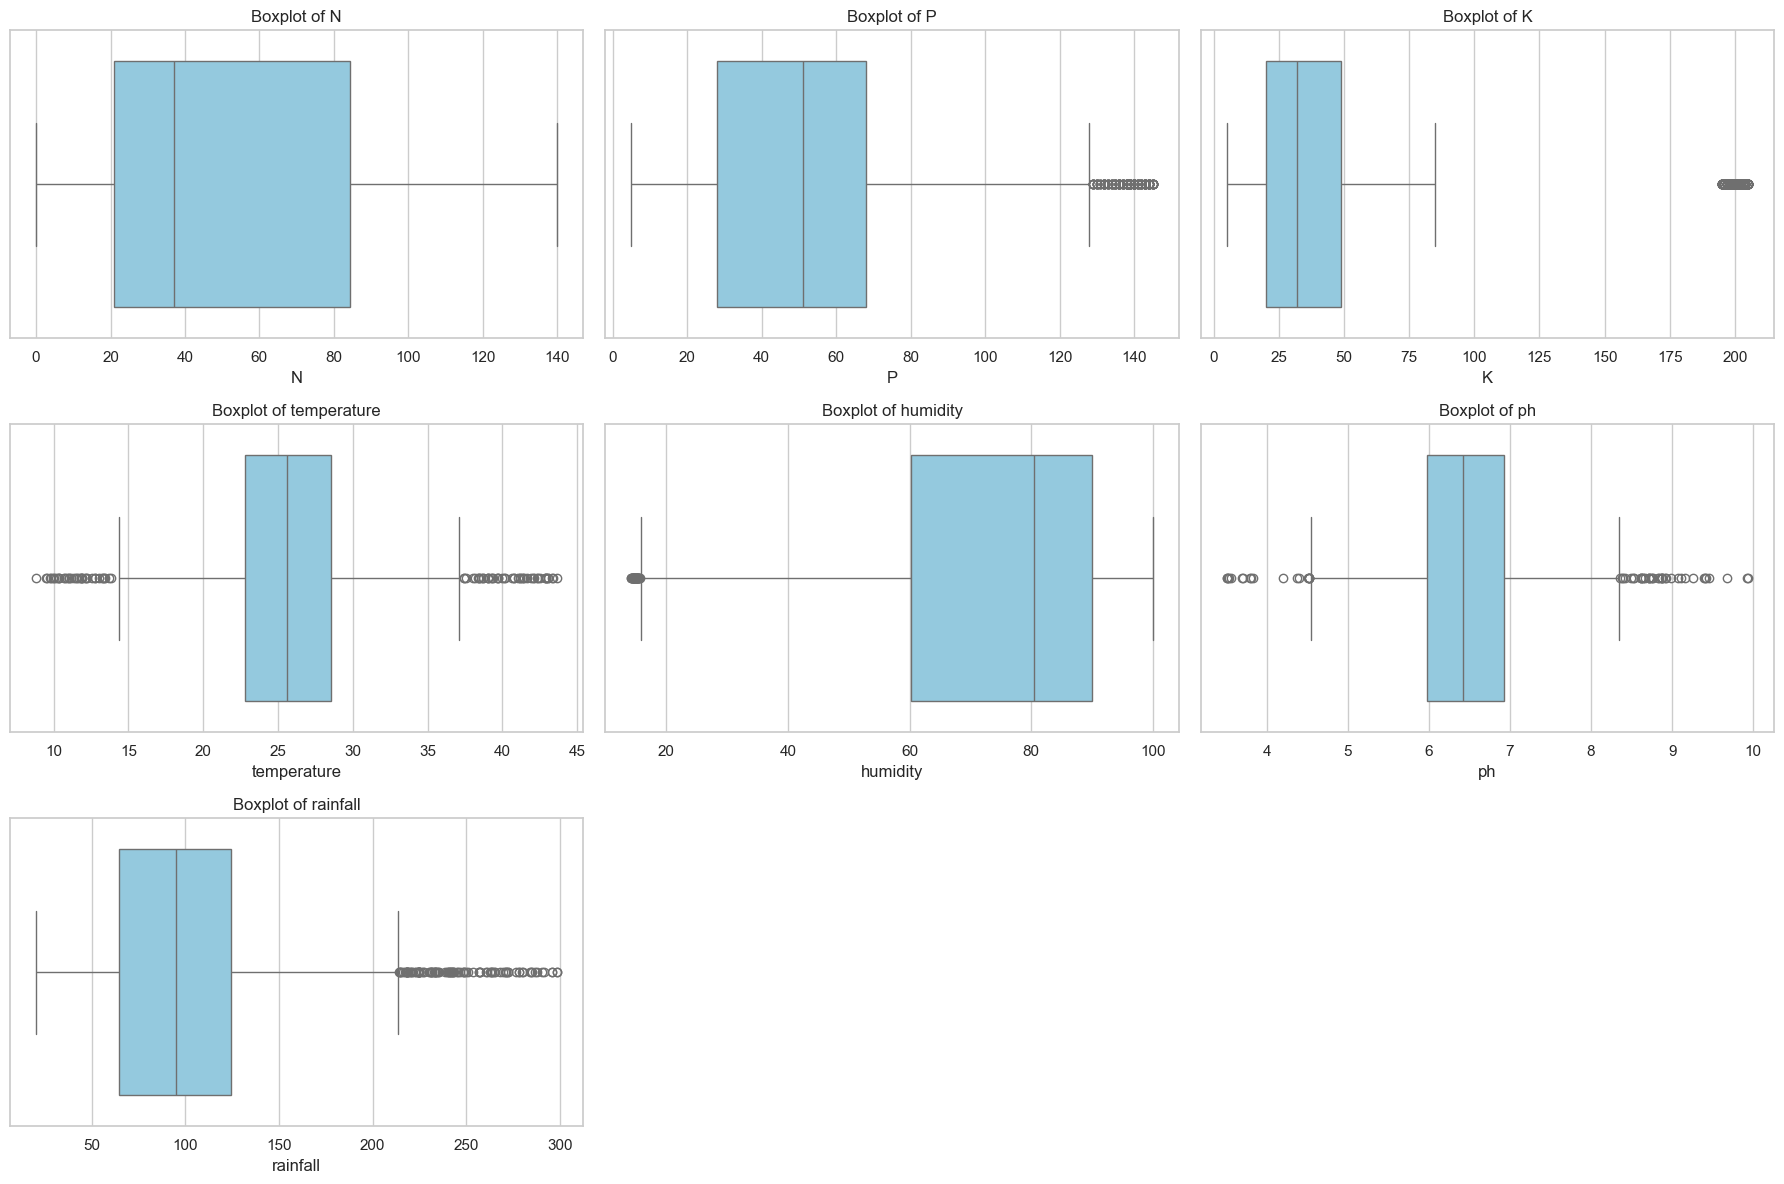

In [7]:
# Numerical features of Crop Dataset

crop_numeric = [
    'N',
    'P',
    'K',
    'temperature',
    'humidity',
    'ph',
    'rainfall'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(crop_numeric):

    sns.boxplot(
        x=crop_df[feature],
        ax=axes[i],
        color='skyblue'
    )

    axes[i].set_title(f'Boxplot of {feature}')

# Remove empty subplots
for j in range(len(crop_numeric), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig("../images/eda/crop/crop_boxplots.png", dpi=300)

plt.show()

## 📖 Interpretation

- **Nitrogen (N):** The distribution is relatively wide with no significant outliers, indicating a broad range of nitrogen levels across different crop samples.

- **Phosphorus (P):** A few high-value outliers are present beyond the upper whisker, suggesting that some crops require substantially higher phosphorus levels than the majority.

- **Potassium (K):** This feature contains several extreme high-value outliers around 190–205. These correspond to crops with exceptionally high potassium requirements and appear to be valid agricultural observations rather than data errors.

- **Temperature:** Most observations are concentrated between approximately 22°C and 29°C, with a small number of lower and higher temperature outliers, indicating crops adapted to diverse climatic conditions.

- **Humidity:** The majority of humidity values lie between 60% and 90%, with very few low-value outliers. Overall, humidity shows a fairly consistent distribution.

- **pH:** Soil pH values are concentrated around the neutral range (6–7). A few acidic and alkaline outliers are observed, representing crops that grow in specialized soil conditions.

- **Rainfall:** Rainfall exhibits several high-value outliers above approximately 200 mm, indicating that certain crops require significantly higher rainfall than most others.

### Overall Observation

The detected outliers primarily reflect the natural variability of agricultural requirements among different crop species. Since the dataset combines multiple crop types with distinct nutrient and environmental needs, these observations are expected and should be retained for model training rather than treated as anomalies.

# Step 7 – Crop Dataset Correlation Heatmap

Analyze the correlation among numerical features in the crop dataset using a correlation heatmap. This helps identify positive and negative relationships between variables, detect highly correlated features, and understand how soil nutrients and environmental factors interact before training machine learning models.

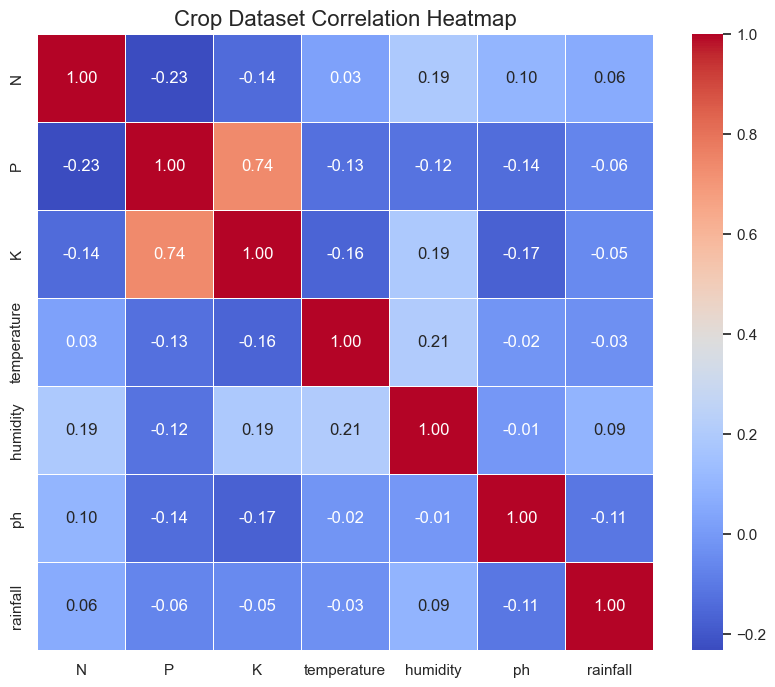

In [8]:
# Select numerical features
crop_numeric = [
    'N',
    'P',
    'K',
    'temperature',
    'humidity',
    'ph',
    'rainfall'
]

# Compute correlation matrix
corr_matrix = crop_df[crop_numeric].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)

plt.title("Crop Dataset Correlation Heatmap", fontsize=16)

# Save figure
plt.savefig(
    "../images/eda/crop/crop_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📖 Interpretation

- The strongest positive correlation is observed between **Phosphorus (P)** and **Potassium (K)** (**0.74**), indicating that these nutrients tend to increase together in the crop dataset.

- **Nitrogen (N)** has a weak negative correlation with **Phosphorus (-0.23)** and **Potassium (-0.14)**, suggesting a slight inverse relationship between nitrogen and the other two primary nutrients.

- **Temperature** and **Humidity** exhibit a weak positive correlation (**0.21**), indicating that warmer conditions are generally associated with slightly higher humidity levels.

- **Humidity** shows weak positive correlations with **Nitrogen (0.19)** and **Potassium (0.19)**, but these relationships are not strong enough to indicate significant dependency.

- **Soil pH** has very weak correlations with all other numerical features, implying that soil acidity/alkalinity varies largely independently of nutrient levels and weather conditions.

- **Rainfall** is nearly uncorrelated with the remaining variables, with correlation coefficients close to zero, suggesting that rainfall behaves as an independent environmental factor within this dataset.

### Overall Observation

The crop dataset exhibits **low multicollinearity**, as most correlation coefficients are weak (between **-0.25 and 0.25**). The only notable relationship exists between **Phosphorus (P)** and **Potassium (K)**. Since no pair of features demonstrates extremely high correlation (e.g., greater than 0.90), all numerical variables can be retained for machine learning model development without concerns of severe redundancy.

# Step 8 – Crop Dataset Target Distribution

Analyze the distribution of crop classes in the dataset to determine whether the target variable is balanced. A balanced class distribution helps ensure that machine learning models learn equally from all crop categories and are not biased toward specific crops.

/var/folders/r1/hw__c24x559dh3x3l6hb5x700000gn/T/ipykernel_31912/2744381097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


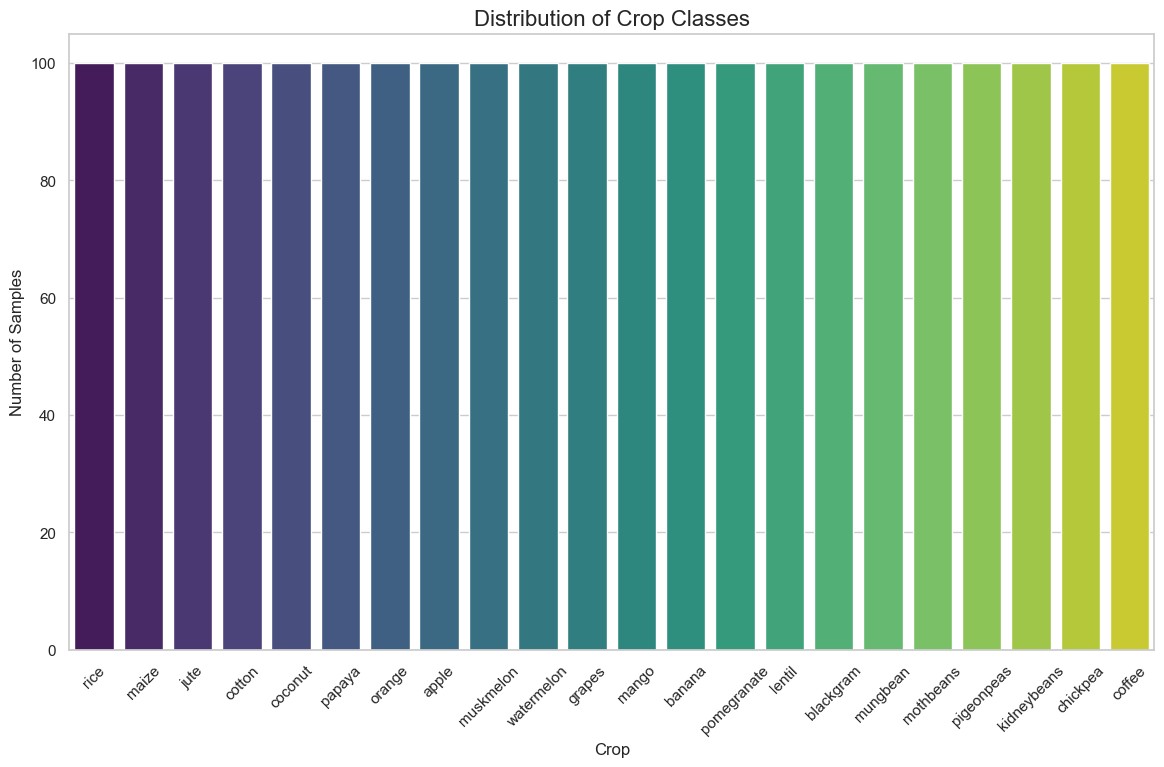


Crop Class Distribution

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(14, 8))

sns.countplot(
    data=crop_df,
    x='label',
    order=crop_df['label'].value_counts().index,
    palette='viridis'
)

plt.title("Distribution of Crop Classes", fontsize=16)
plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

# Save figure
plt.savefig(
    "../images/eda/crop/crop_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Display class frequencies
crop_counts = crop_df['label'].value_counts().sort_values(ascending=False)

print("\nCrop Class Distribution\n")
print(crop_counts)

## 📖 Interpretation

- The Crop Recommendation dataset is perfectly balanced, with all 22 crop classes containing exactly 100 samples each.
- No crop class is overrepresented or underrepresented, indicating the absence of class imbalance.
- A balanced class distribution ensures that machine learning models can learn patterns from each crop category equally, reducing prediction bias.
- Since all classes have the same number of observations, evaluation metrics such as Accuracy, Precision, Recall, and F1-Score will provide a fair assessment of model performance.
- The balanced nature of the dataset eliminates the need for class balancing techniques such as Oversampling, Undersampling, or SMOTE before model training.
- Overall, the dataset is well-suited for developing a robust and unbiased multi-class crop recommendation model.

# Step 9 – Fertilizer Dataset Histograms

Analyze the distribution of all numerical features in the Fertilizer Recommendation dataset using histograms. This visualization helps understand the spread, central tendency, variability, and skewness of each feature while identifying potential outliers or unusual patterns. Understanding these distributions provides valuable insights into the dataset and supports informed decisions during feature engineering and machine learning model development.

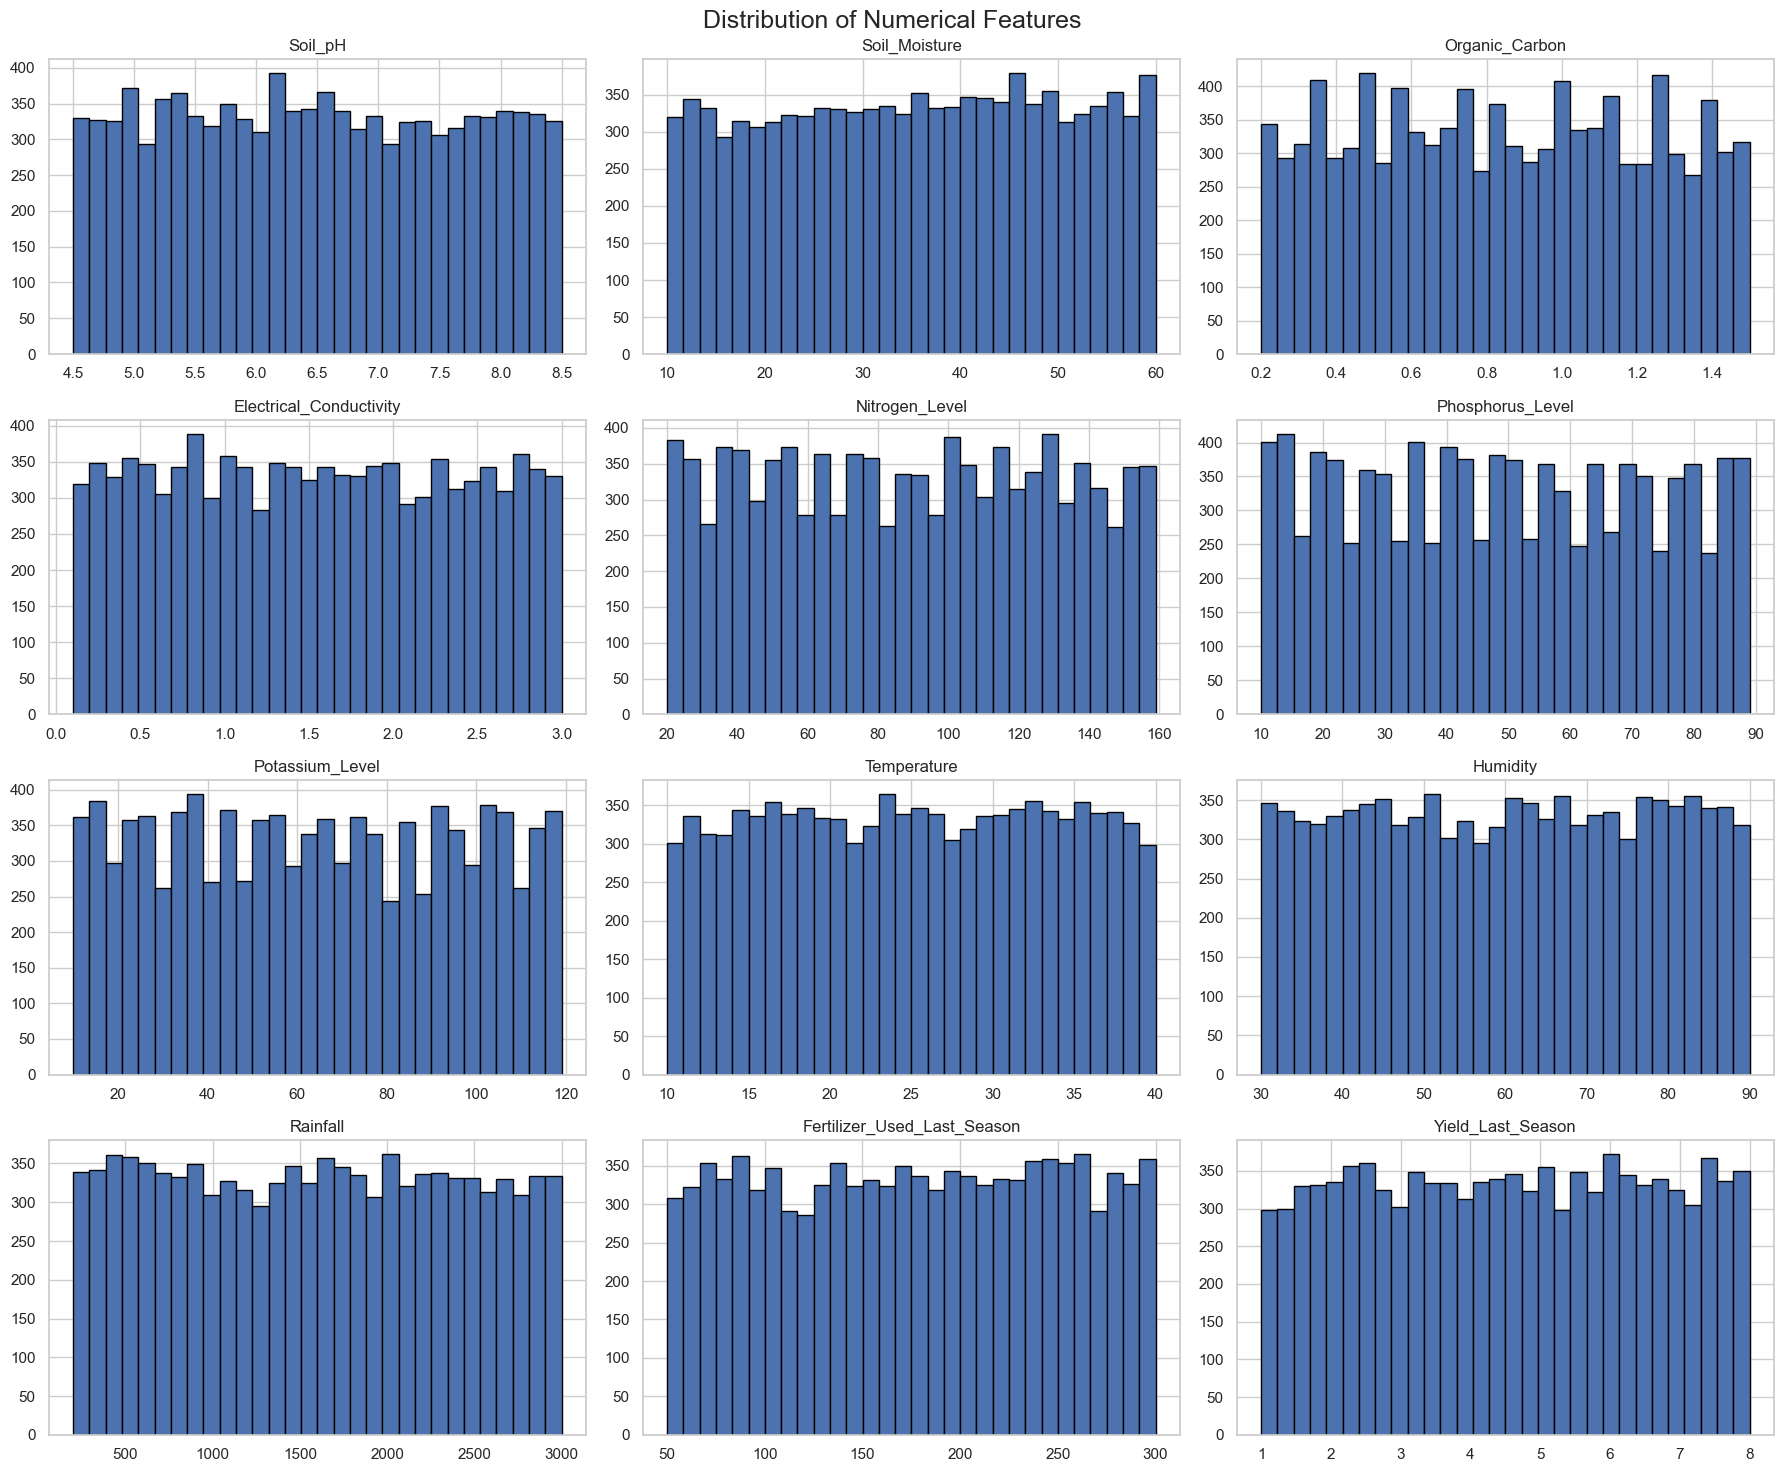

In [10]:
# Numerical features
numerical_features = [
    'Soil_pH',
    'Soil_Moisture',
    'Organic_Carbon',
    'Electrical_Conductivity',
    'Nitrogen_Level',
    'Phosphorus_Level',
    'Potassium_Level',
    'Temperature',
    'Humidity',
    'Rainfall',
    'Fertilizer_Used_Last_Season',
    'Yield_Last_Season'
]

# Plot histograms
fertilizer_df[numerical_features].hist(
    figsize=(18, 15),
    bins=30,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.tight_layout()

# Save visualization
plt.savefig(
    "../images/eda/fertilizer/fertilizer_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📖 Interpretation

- The numerical features in the Fertilizer Recommendation dataset exhibit fairly uniform distributions, indicating that the data has been generated or collected across a wide range of values without significant concentration around specific intervals.
- Soil properties such as **Soil_pH**, **Soil_Moisture**, **Organic_Carbon**, and **Electrical_Conductivity** are evenly distributed, ensuring that the model is exposed to diverse soil conditions.
- Nutrient-related features (**Nitrogen_Level**, **Phosphorus_Level**, and **Potassium_Level**) cover their entire value ranges with no noticeable skewness, providing balanced nutrient information for fertilizer prediction.
- Environmental features including **Temperature**, **Humidity**, and **Rainfall** are also well distributed, allowing the model to learn from various climatic conditions.
- Historical agricultural features such as **Fertilizer_Used_Last_Season** and **Yield_Last_Season** show consistent distributions, indicating that previous farming practices and yield records are adequately represented.
- No severe skewness, abnormal peaks, or obvious outliers are observed in the numerical features, suggesting good data quality for subsequent preprocessing and machine learning model development.
- Overall, the numerical variables appear well distributed and suitable for exploratory analysis, feature engineering, and predictive modeling.

# Step 10 – Fertilizer Dataset Boxplots

Visualize the numerical features of the Fertilizer Recommendation dataset using boxplots to identify the presence of outliers, examine the spread of the data, and understand the variability of each feature. This analysis helps determine whether any preprocessing techniques, such as outlier treatment or feature scaling, may be required before model training.

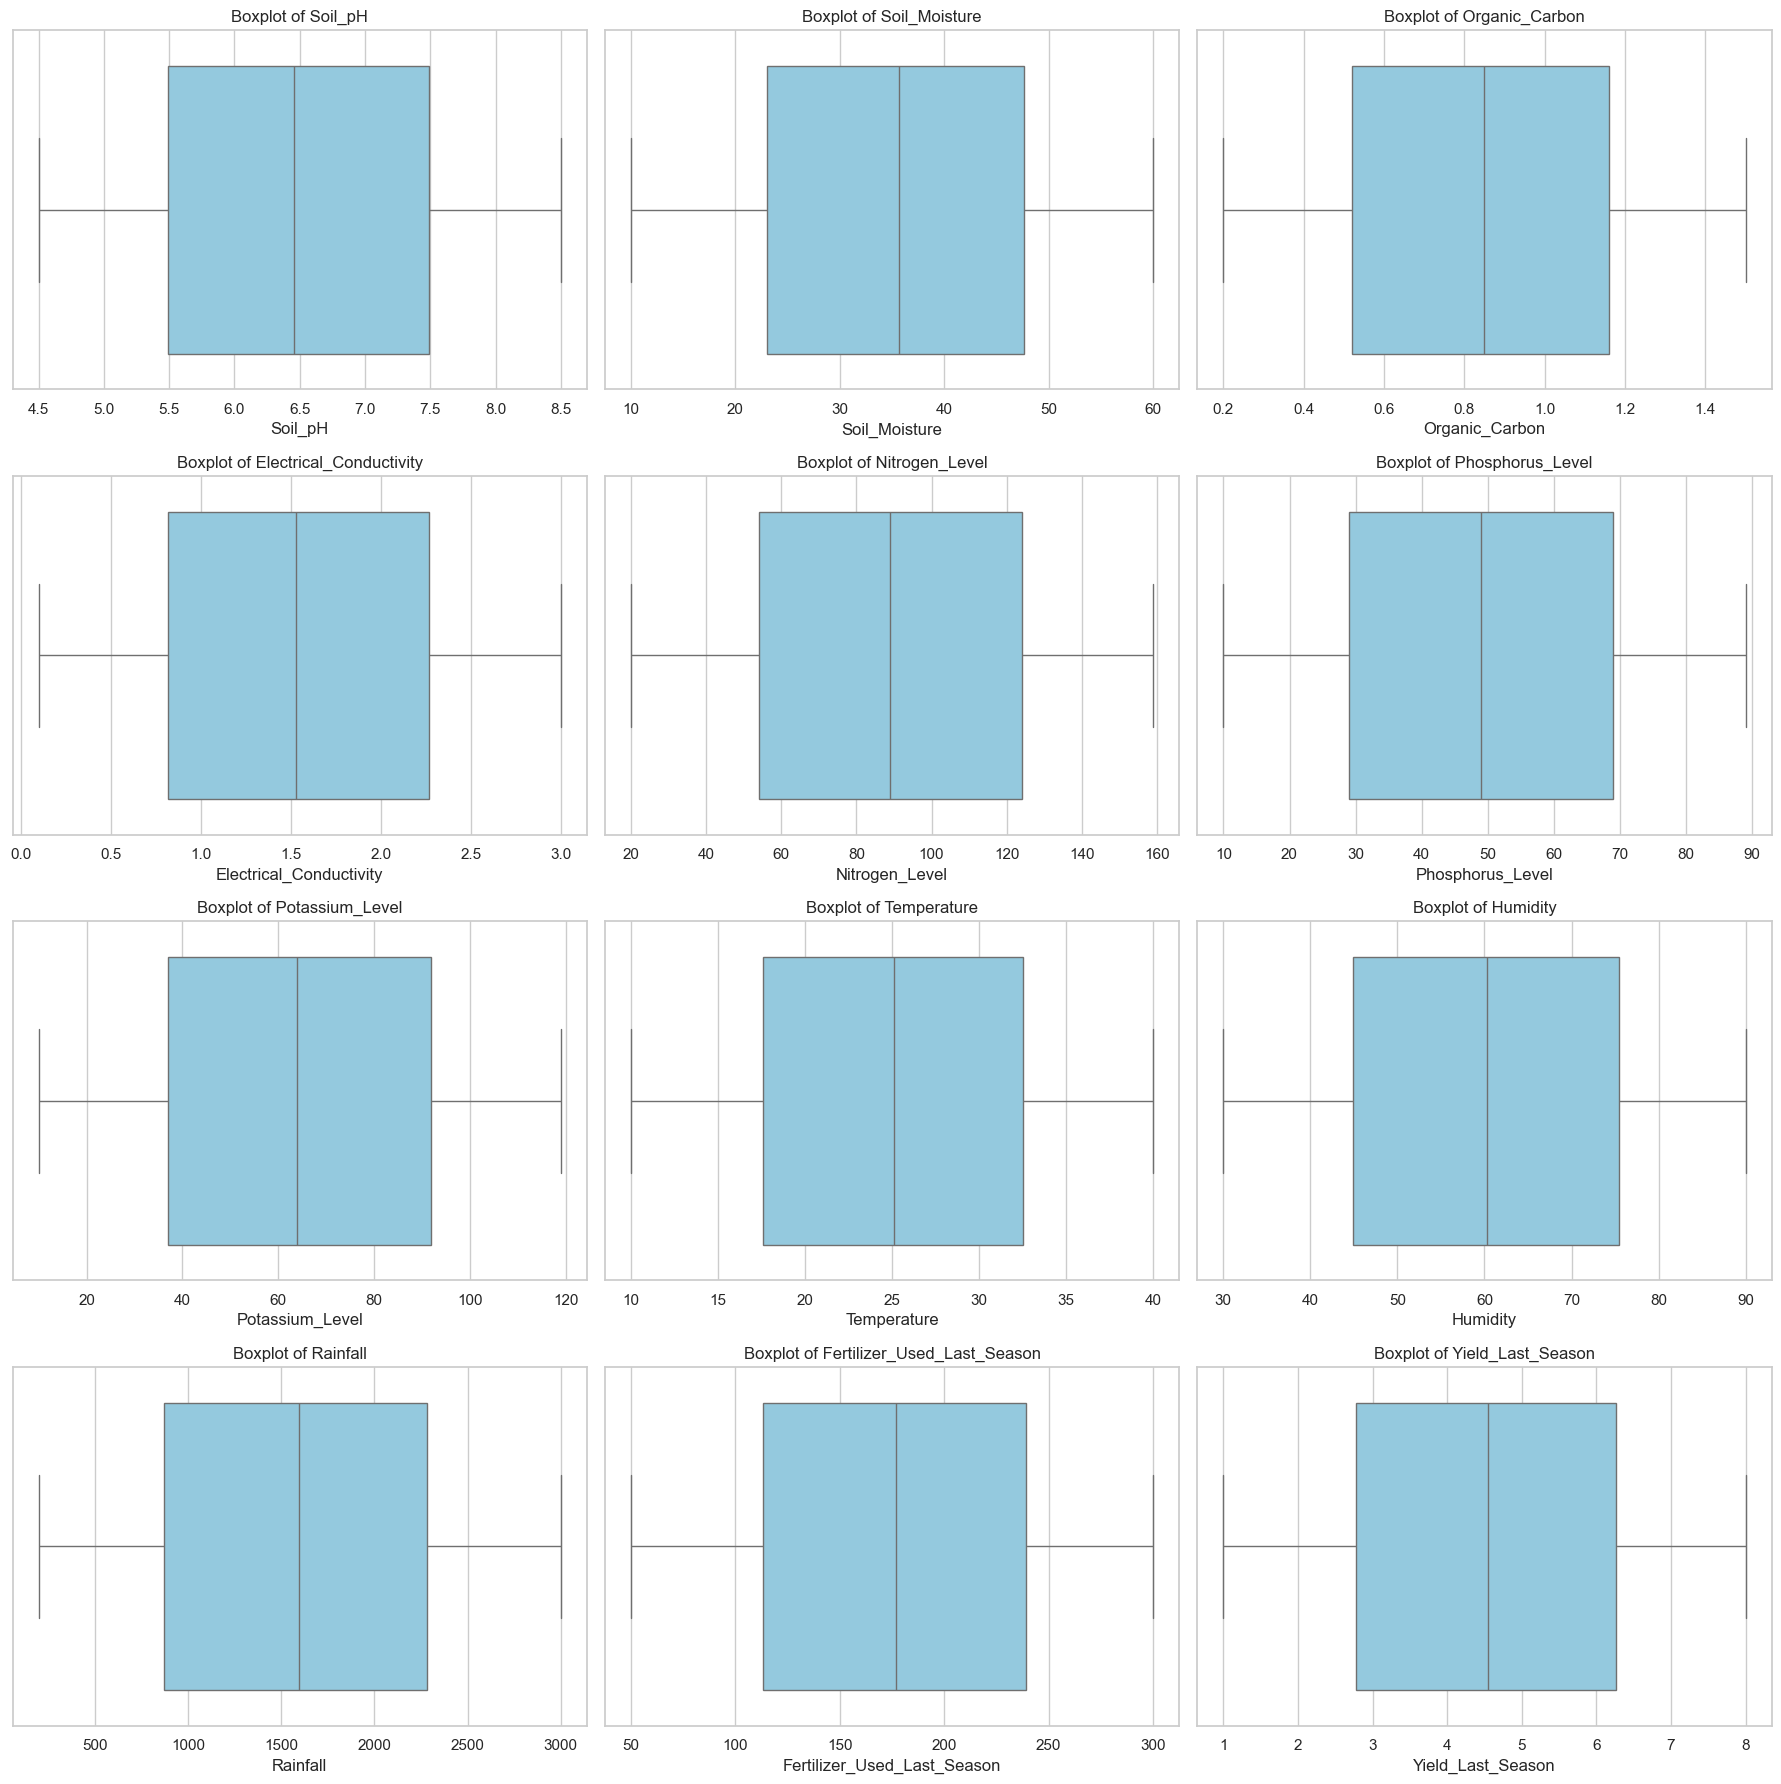

In [11]:
# Numerical features
numerical_features = [
    'Soil_pH',
    'Soil_Moisture',
    'Organic_Carbon',
    'Electrical_Conductivity',
    'Nitrogen_Level',
    'Phosphorus_Level',
    'Potassium_Level',
    'Temperature',
    'Humidity',
    'Rainfall',
    'Fertilizer_Used_Last_Season',
    'Yield_Last_Season'
]

# Create subplots
fig, axes = plt.subplots(4, 3, figsize=(18, 18))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        x=fertilizer_df[feature],
        color="skyblue",
        ax=axes[i]
    )
    axes[i].set_title(f"Boxplot of {feature}")

plt.tight_layout()

# Save figure
plt.savefig(
    "../images/eda/fertilizer/fertilizer_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Step 11 – Fertilizer Dataset Boxplots

Visualize the numerical features of the fertilizer dataset using boxplots to detect the presence of outliers, understand the spread of the data, and analyze the distribution of each feature. This helps identify abnormal values that may influence model performance and determines whether further preprocessing is required.

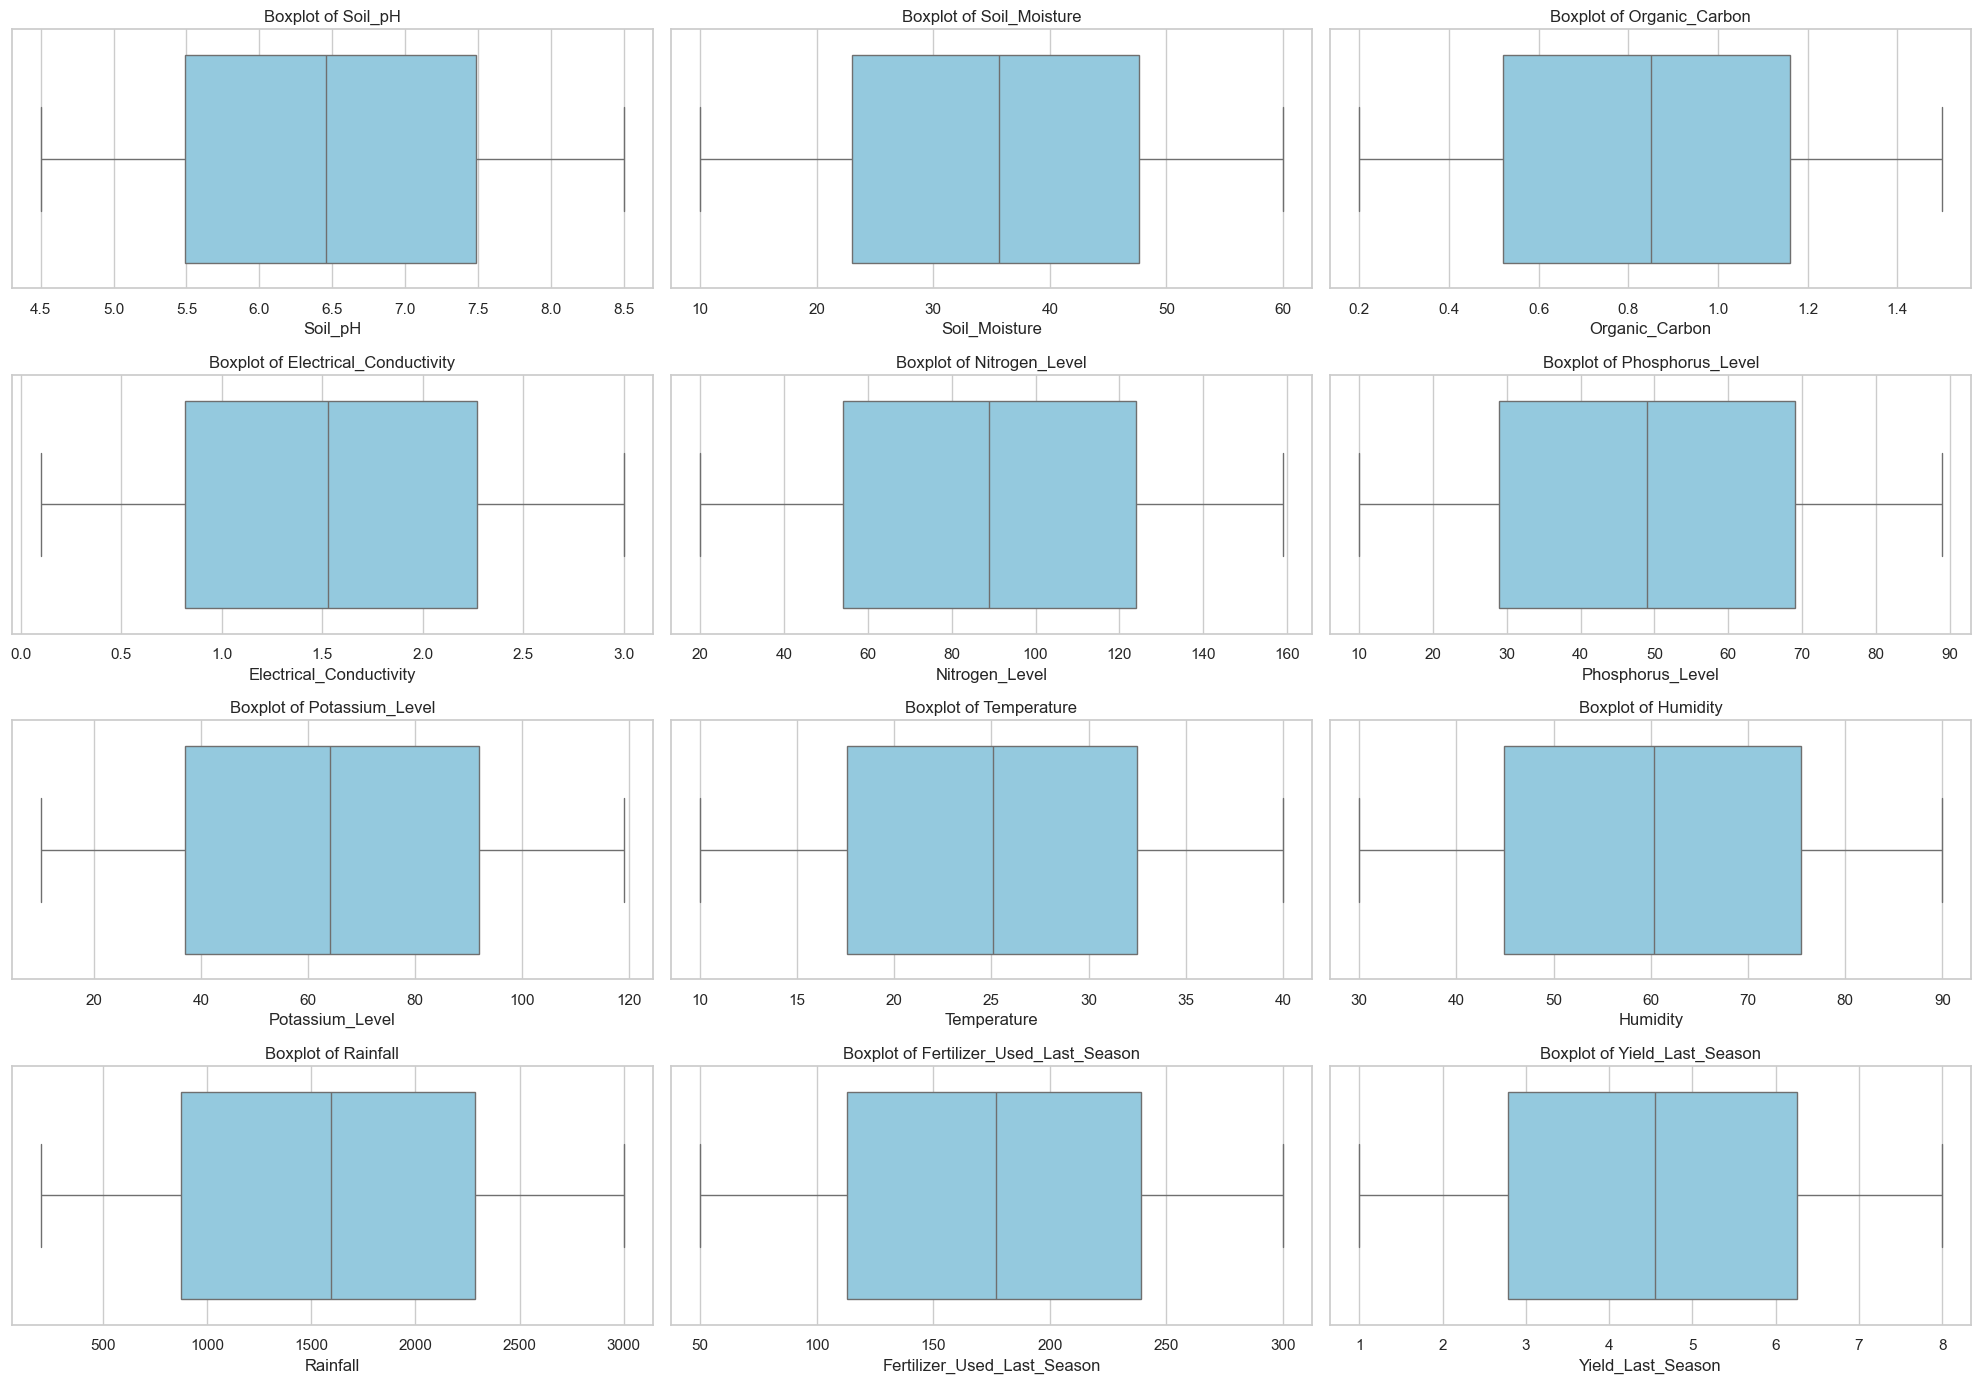

In [12]:
numerical_columns = fertilizer_df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 14))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=fertilizer_df[column], color='skyblue')
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)

plt.tight_layout()

# Save figure
plt.savefig(
    "../images/eda/fertilizer/fertilizer_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📊 Interpretation

- The boxplots indicate that all numerical features exhibit a fairly uniform distribution with no significant outliers.

- Soil_pH ranges approximately from 4.5 to 8.5, covering acidic to slightly alkaline soils without extreme values.

- Soil_Moisture, Organic_Carbon, Electrical_Conductivity, Nitrogen_Level, Phosphorus_Level, and Potassium_Level all display balanced distributions with symmetric interquartile ranges.

- Weather-related variables (Temperature, Humidity, and Rainfall) also show consistent variability and do not contain abnormal observations.

- Fertilizer_Used_Last_Season and Yield_Last_Season have evenly distributed values and no unusual deviations from the rest of the dataset.

- Unlike the crop dataset, where a few variables showed noticeable outliers, the fertilizer dataset appears clean and well-distributed.

- Overall, the fertilizer dataset demonstrates excellent data quality, indicating that no immediate outlier removal is required before proceeding to feature encoding and machine learning.

# Step 12 – Fertilizer Dataset Correlation Heatmap

Analyze the relationships among the numerical features of the fertilizer dataset using a correlation heatmap. This helps identify strongly correlated variables, detect redundant features, and understand how different soil properties, weather conditions, and nutrient levels are related before proceeding to feature engineering and machine learning.

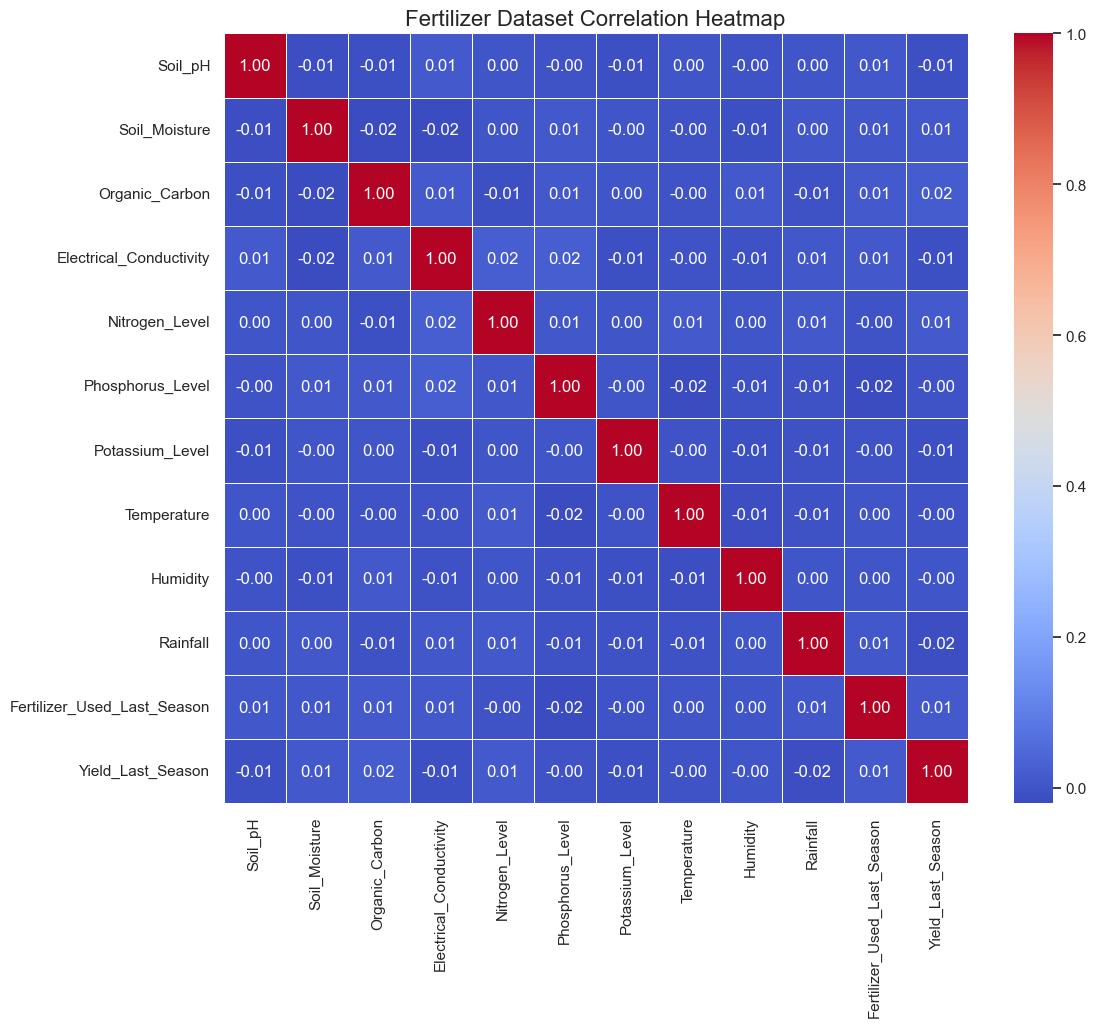

In [13]:
# Select only numerical columns
fertilizer_numeric = fertilizer_df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
fertilizer_corr = fertilizer_numeric.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    fertilizer_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Fertilizer Dataset Correlation Heatmap", fontsize=16)

# Save figure
plt.savefig(
    "../images/eda/fertilizer/fertilizer_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📊 Interpretation

- The correlation heatmap indicates that there are no strong linear relationships among the numerical features in the fertilizer dataset.

- Most correlation coefficients are very close to **0**, ranging approximately between **-0.02 and 0.02**, suggesting that the features are largely independent of one another.

- Soil properties such as **Soil_pH, Soil_Moisture, Organic_Carbon,** and **Electrical_Conductivity** show negligible correlation with nutrient levels and environmental variables.

- The nutrient-related features (**Nitrogen_Level, Phosphorus_Level,** and **Potassium_Level**) are also nearly uncorrelated, indicating that each nutrient provides unique information.

- Environmental variables (**Temperature, Humidity,** and **Rainfall**) do not exhibit meaningful correlations with the soil characteristics or nutrient measurements.

- **Fertilizer_Used_Last_Season** and **Yield_Last_Season** also have very weak correlations with the remaining numerical variables, suggesting that these variables contribute independently to the dataset.

- Overall, the absence of strong correlations indicates **low multicollinearity** among the numerical features. Therefore, all numerical variables can be retained for model training without concerns about redundancy caused by highly correlated features.

# Step 13 – Fertilizer Dataset Categorical Feature Distribution

Analyze the distribution of all categorical features in the fertilizer dataset to understand the frequency of different categories, identify any class imbalance, and gain insights into the composition of the dataset. This analysis helps verify that the categorical variables are well represented before applying encoding techniques during data preprocessing.

/var/folders/r1/hw__c24x559dh3x3l6hb5x700000gn/T/ipykernel_31912/873688045.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


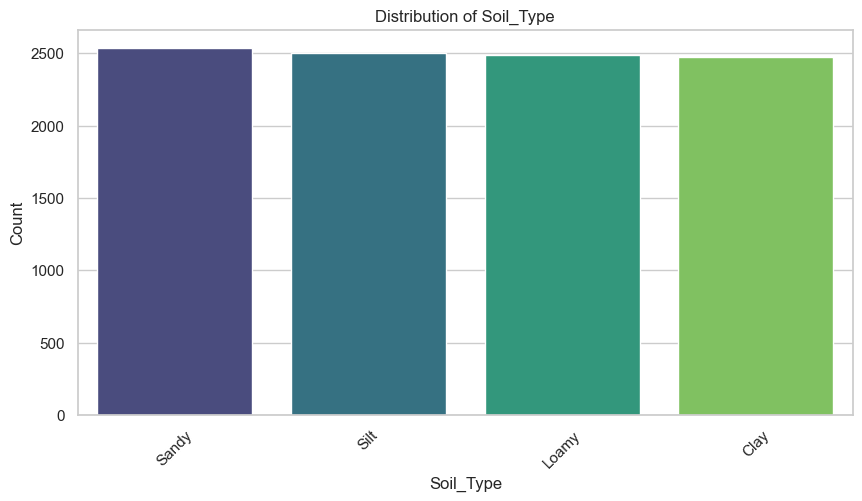


Soil_Type Distribution

Soil_Type
Sandy    2536
Silt     2501
Loamy    2486
Clay     2477
Name: count, dtype: int64


/var/folders/r1/hw__c24x559dh3x3l6hb5x700000gn/T/ipykernel_31912/873688045.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


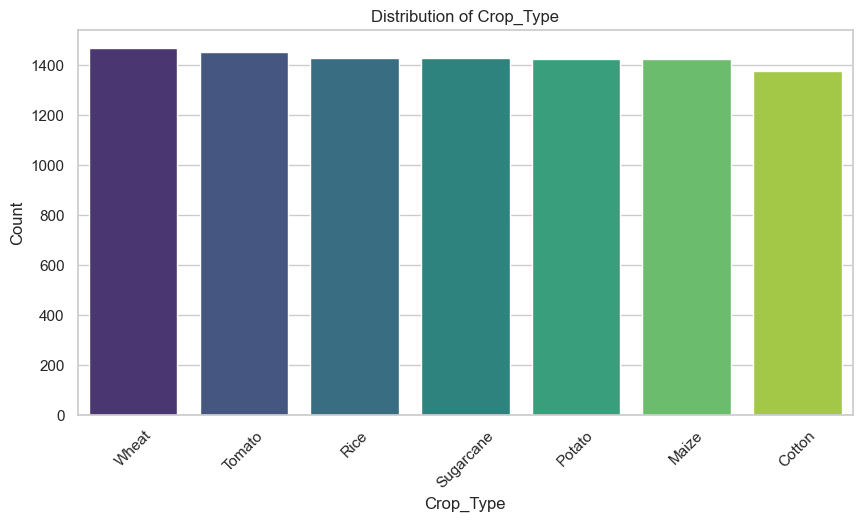


Crop_Type Distribution

Crop_Type
Wheat        1467
Tomato       1451
Rice         1429
Sugarcane    1428
Potato       1425
Maize        1424
Cotton       1376
Name: count, dtype: int64


/var/folders/r1/hw__c24x559dh3x3l6hb5x700000gn/T/ipykernel_31912/873688045.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


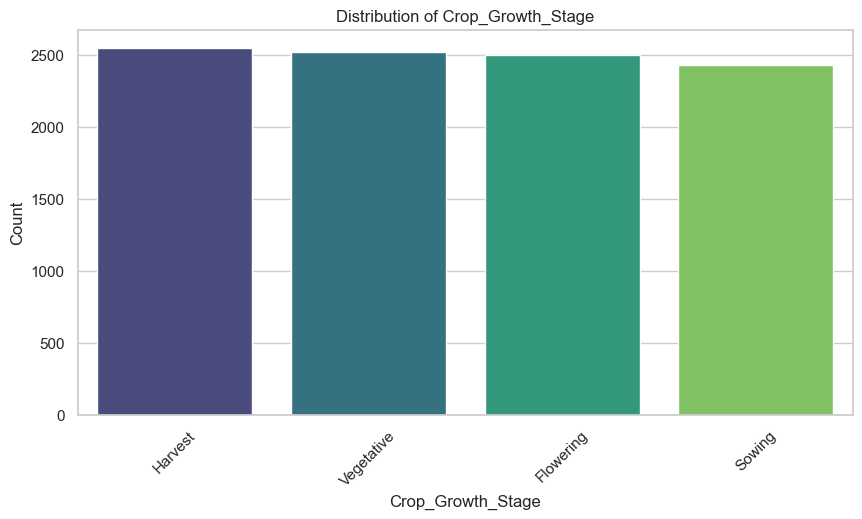


Crop_Growth_Stage Distribution

Crop_Growth_Stage
Harvest       2547
Vegetative    2524
Flowering     2499
Sowing        2430
Name: count, dtype: int64


/var/folders/r1/hw__c24x559dh3x3l6hb5x700000gn/T/ipykernel_31912/873688045.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


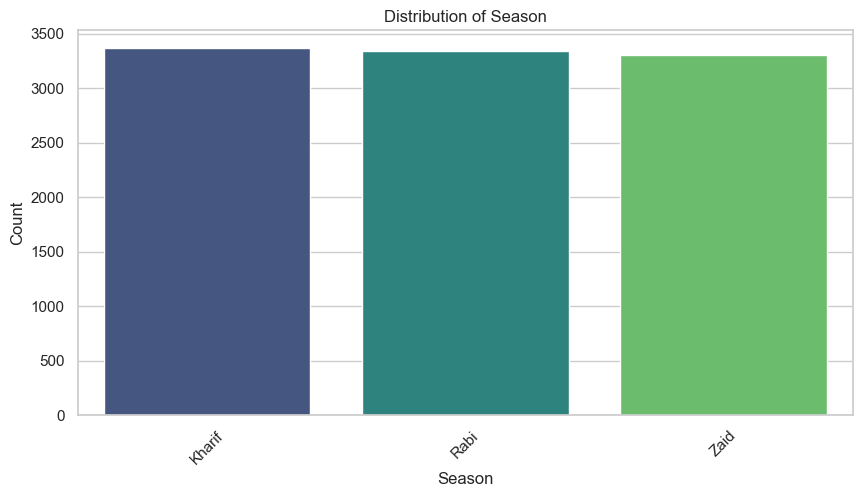


Season Distribution

Season
Kharif    3363
Rabi      3337
Zaid      3300
Name: count, dtype: int64


/var/folders/r1/hw__c24x559dh3x3l6hb5x700000gn/T/ipykernel_31912/873688045.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


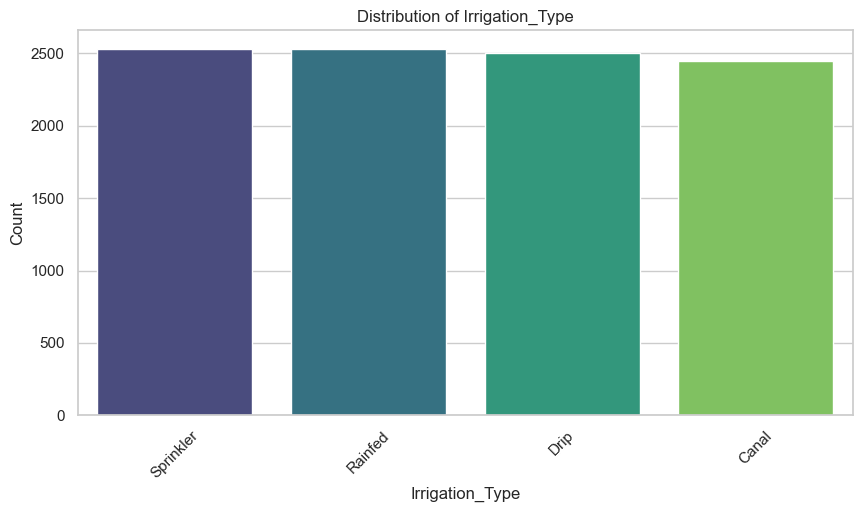


Irrigation_Type Distribution

Irrigation_Type
Sprinkler    2531
Rainfed      2526
Drip         2499
Canal        2444
Name: count, dtype: int64


/var/folders/r1/hw__c24x559dh3x3l6hb5x700000gn/T/ipykernel_31912/873688045.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


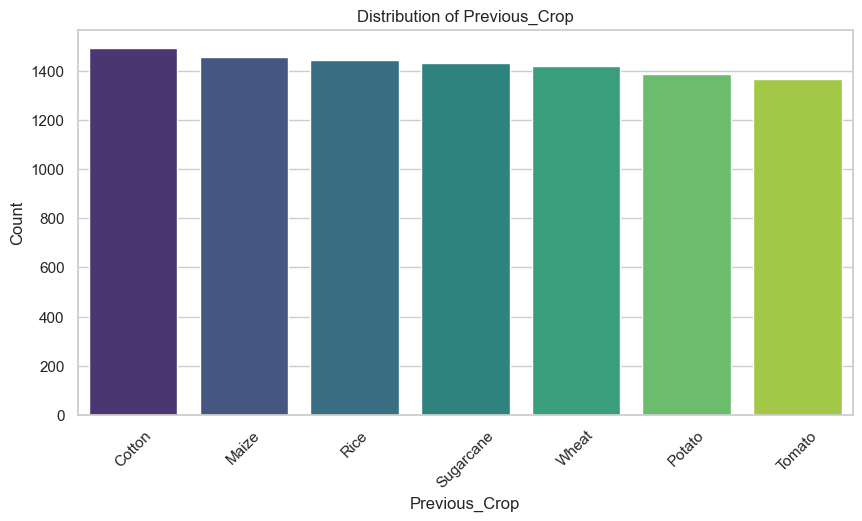


Previous_Crop Distribution

Previous_Crop
Cotton       1492
Maize        1458
Rice         1446
Sugarcane    1433
Wheat        1418
Potato       1387
Tomato       1366
Name: count, dtype: int64


/var/folders/r1/hw__c24x559dh3x3l6hb5x700000gn/T/ipykernel_31912/873688045.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


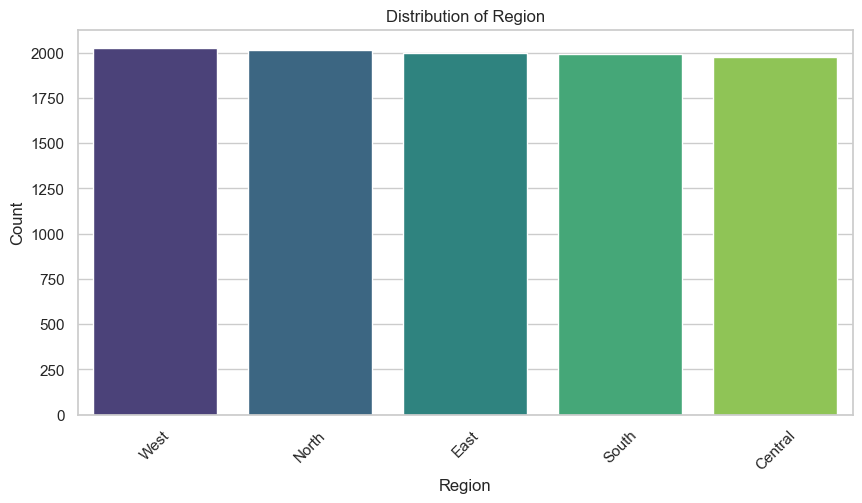


Region Distribution

Region
West       2026
North      2012
East       1998
South      1990
Central    1974
Name: count, dtype: int64


/var/folders/r1/hw__c24x559dh3x3l6hb5x700000gn/T/ipykernel_31912/873688045.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


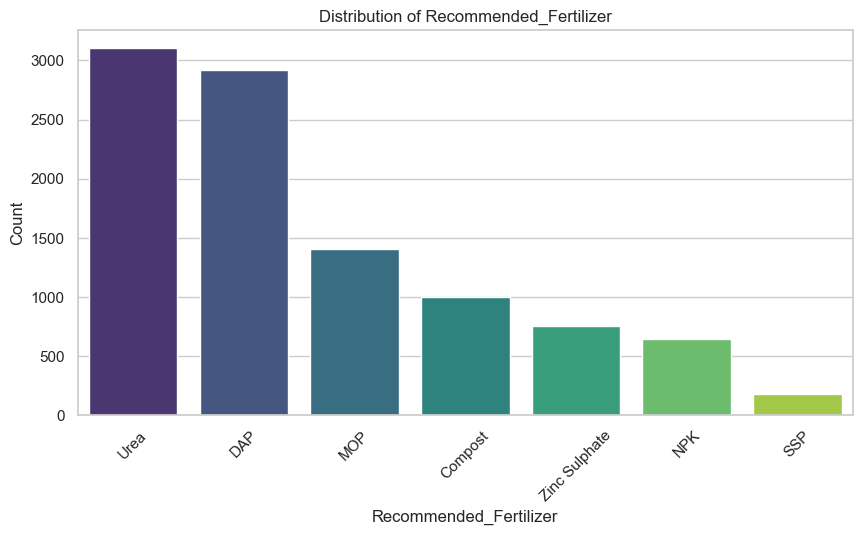


Recommended_Fertilizer Distribution

Recommended_Fertilizer
Urea             3101
DAP              2920
MOP              1408
Compost           996
Zinc Sulphate     752
NPK               641
SSP               182
Name: count, dtype: int64


In [14]:
categorical_columns = fertilizer_df.select_dtypes(include='object').columns

for column in categorical_columns:
    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=fertilizer_df,
        x=column,
        order=fertilizer_df[column].value_counts().index,
        palette='viridis'
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    # Save figure
    plt.savefig(
        f"../images/eda/fertilizer/{column.lower()}_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"\n{column} Distribution\n")
    print(fertilizer_df[column].value_counts())

## 📊 Interpretation

- Most categorical features are **well balanced**, ensuring that the machine learning model receives sufficient training examples for each category.
- The balanced distributions of Region, Previous Crop, Irrigation Type, Season, Crop Growth Stage, Crop Type, and Soil Type reduce the likelihood of bias during model training.
- The **Recommended_Fertilizer** target variable is the only feature showing **class imbalance**, with **Urea** and **DAP** appearing much more frequently than fertilizers such as **SSP**, **NPK**, and **Zinc Sulphate**.
- During model evaluation, performance metrics such as **Precision**, **Recall**, **F1-Score**, and the **Confusion Matrix** should be considered alongside accuracy to ensure that minority fertilizer classes are predicted effectively.
- Overall, the dataset demonstrates a strong balance across input features and is suitable for building a robust fertilizer recommendation model after appropriate preprocessing.

## Step 14 – Relationship Analysis Between Features and Target Variable

Analyze how the input features influence the **Recommended_Fertilizer** target variable. This analysis helps identify important patterns and relationships between agricultural conditions and fertilizer recommendations, providing insights before model training.

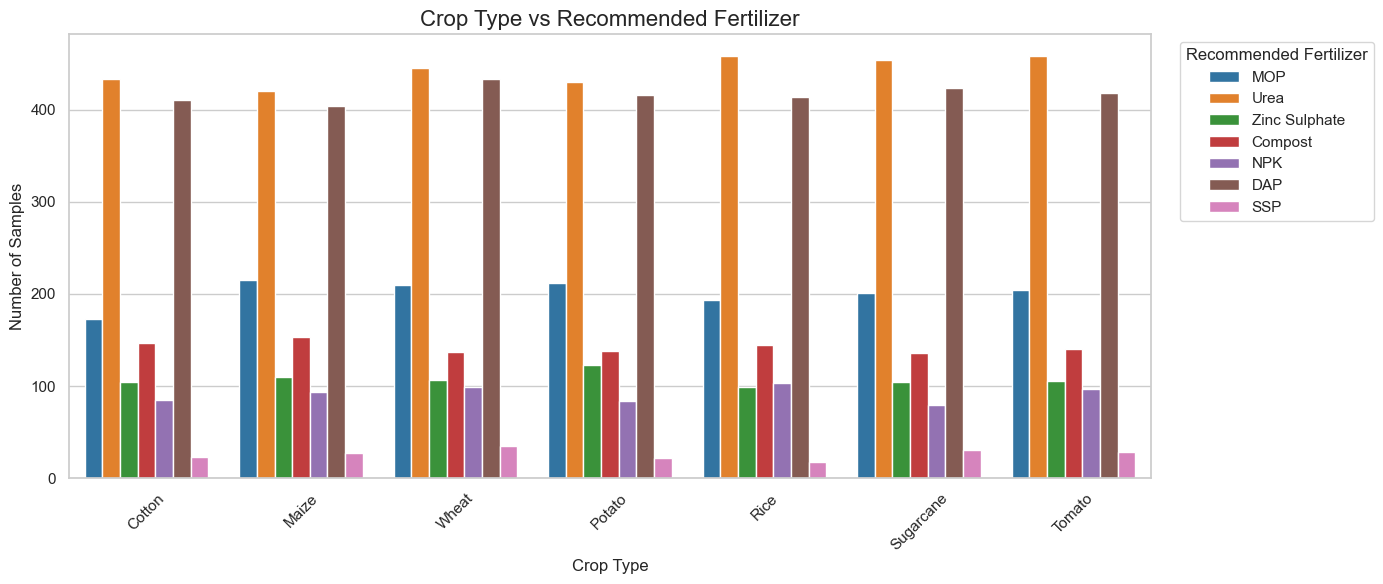

In [15]:
# Step 14.1 - Crop Type vs Recommended Fertilizer

plt.figure(figsize=(14, 6))

sns.countplot(
    data=fertilizer_df,
    x='Crop_Type',
    hue='Recommended_Fertilizer',
    palette='tab10'
)

plt.title("Crop Type vs Recommended Fertilizer", fontsize=16)
plt.xlabel("Crop Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.legend(
    title="Recommended Fertilizer",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()

plt.savefig(
    "../images/eda/fertilizer/crop_type_vs_fertilizer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### **Interpretation**

- **Urea** and **DAP** are the most frequently recommended fertilizers across all crop types, indicating they are the primary nutrient sources for most crops in the dataset.
- **MOP**, **Compost**, **Zinc Sulphate**, and **NPK** are recommended in moderate quantities, while **SSP** has the lowest recommendation frequency for every crop.
- The fertilizer recommendation pattern remains consistent across all crop types, with only minor differences in counts.
- This suggests that fertilizer recommendations are influenced by multiple factors (such as soil nutrients, soil type, and crop conditions) rather than crop type alone.

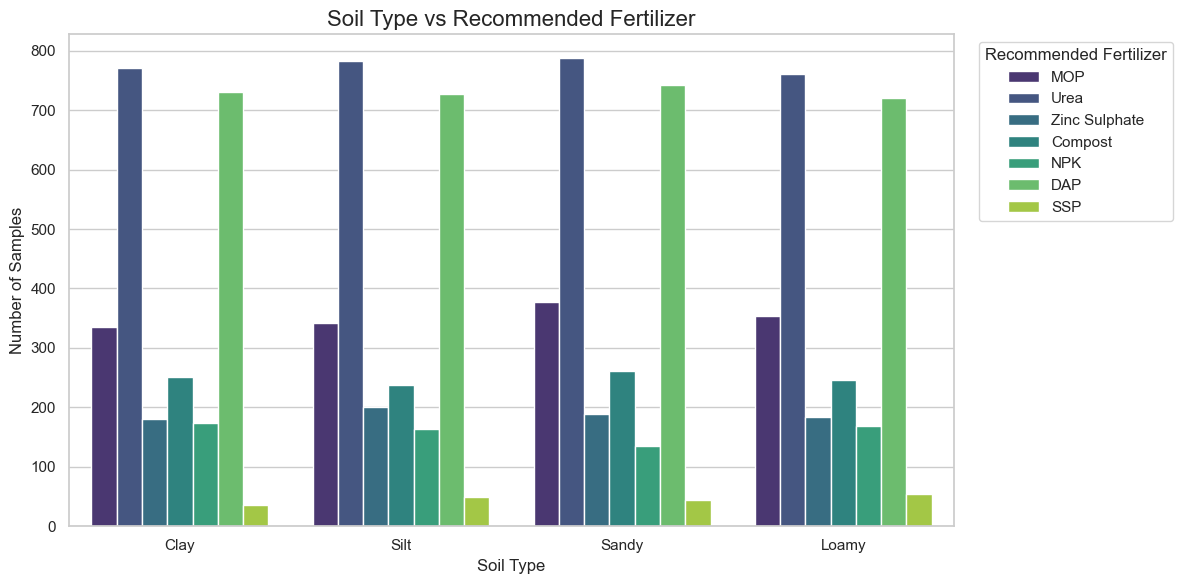

In [17]:
# Step 14.2 - Crop Type vs Recommended Fertilizer

plt.figure(figsize=(12, 6))

sns.countplot(
    data=fertilizer_df,
    x='Soil_Type',
    hue='Recommended_Fertilizer',
    palette='viridis'
)

plt.title('Soil Type vs Recommended Fertilizer', fontsize=16)
plt.xlabel('Soil Type')
plt.ylabel('Number of Samples')
plt.legend(title='Recommended Fertilizer', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

plt.savefig(
    "../images/eda/fertilizer/soil_type_vs_recommended_fertilizer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- Urea is the most frequently recommended fertilizer across all soil types (Clay, Silt, Sandy, and Loamy), with consistently high recommendation counts.
- DAP is the second most recommended fertilizer and follows a distribution pattern similar to Urea across every soil type.
- MOP and Compost are recommended at moderate levels, indicating their importance for maintaining soil potassium and organic matter under different soil conditions.
- Zinc Sulphate and NPK receive comparatively fewer recommendations, suggesting they are required only under specific nutrient deficiencies or crop requirements.
- SSP is the least recommended fertilizer across all soil types, indicating limited usage in the dataset.
- The recommendation pattern remains fairly consistent across all soil types, implying that fertilizer selection is influenced by multiple agricultural factors (such as crop type, nutrient levels, and growth stage) rather than soil type alone.

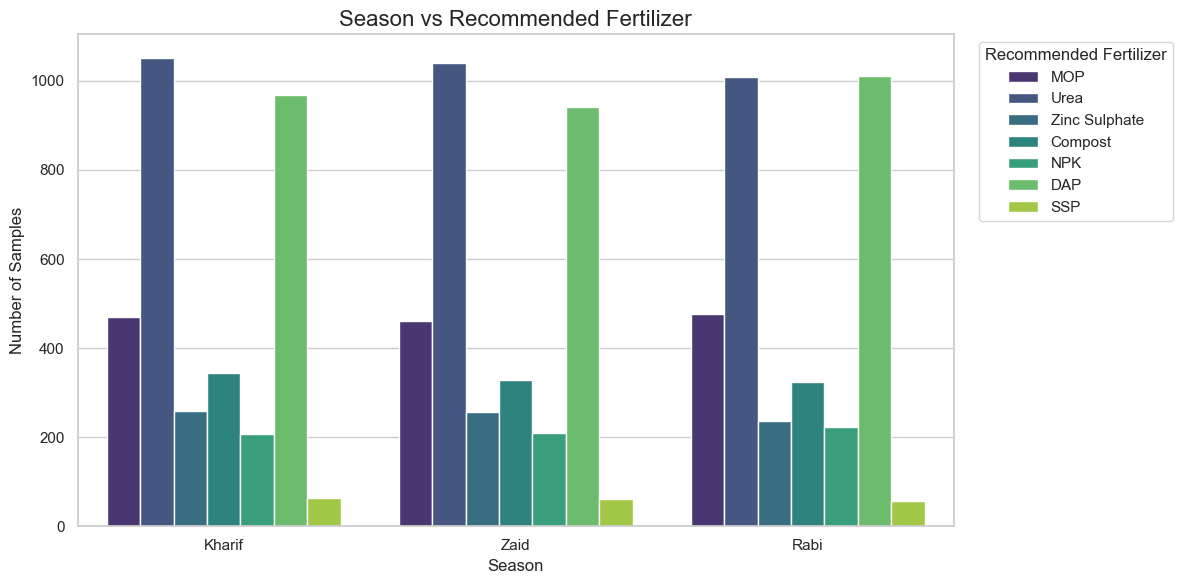

In [18]:
# Step 14.3 - Season vs Recommended Fertilizer

plt.figure(figsize=(12, 6))

sns.countplot(
    data=fertilizer_df,
    x="Season",
    hue="Recommended_Fertilizer",
    palette="viridis"
)

plt.title("Season vs Recommended Fertilizer", fontsize=16)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Recommended Fertilizer", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

# Save the figure
plt.savefig(
    "../images/eda/fertilizer/season_vs_recommended_fertilizer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- Urea is the most recommended fertilizer across all three seasons (Kharif, Rabi, and Zaid), indicating its consistent importance for crop nutrition throughout the year.
- DAP is the second most frequently recommended fertilizer in every season, with slightly higher recommendations during the Rabi season.
- MOP and Compost show moderate recommendation frequencies across all seasons, suggesting their regular use irrespective of seasonal variations.
- Zinc Sulphate and NPK receive comparatively fewer recommendations, indicating that they are applied only under specific nutrient or crop requirements.
- SSP is the least recommended fertilizer in all seasons, reflecting its limited usage in the dataset.
- Overall, fertilizer recommendation patterns remain fairly consistent across seasons, suggesting that recommendations depend more on factors such as soil nutrients, crop type, and crop growth stage than on the season alone.

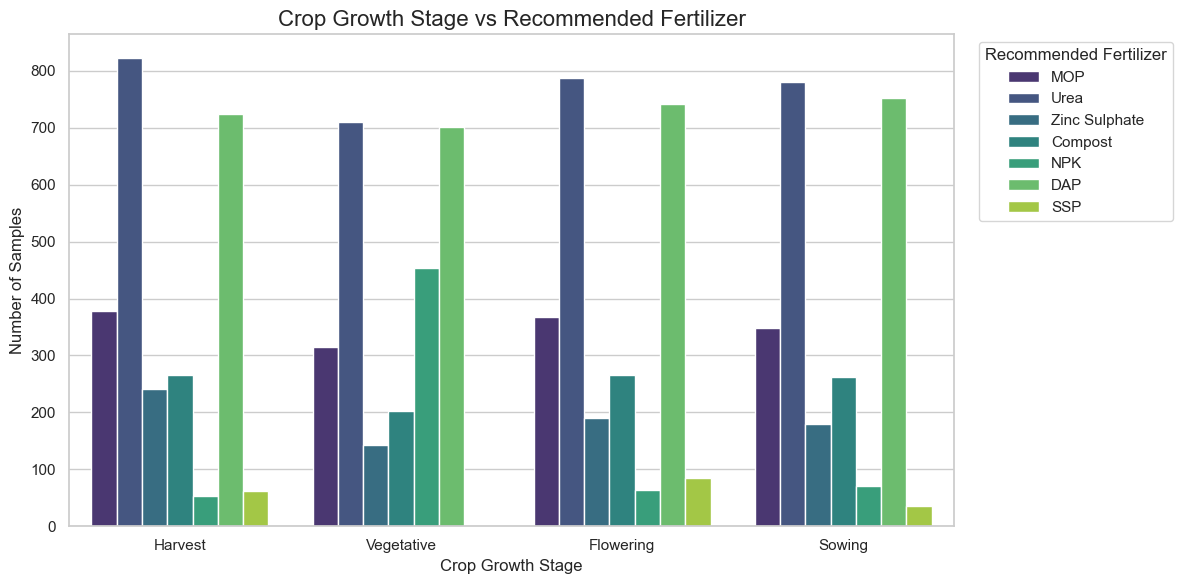

In [19]:
# Step 14.4 - Crop Growth Stage vs Recommended Fertilizer

plt.figure(figsize=(12, 6))

sns.countplot(
    data=fertilizer_df,
    x="Crop_Growth_Stage",
    hue="Recommended_Fertilizer",
    palette="viridis"
)

plt.title("Crop Growth Stage vs Recommended Fertilizer", fontsize=16)
plt.xlabel("Crop Growth Stage", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Recommended Fertilizer", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

# Save the figure
plt.savefig(
    "../images/eda/fertilizer/crop_growth_stage_vs_recommended_fertilizer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- Urea is the most recommended fertilizer across all crop growth stages, indicating its consistent role in meeting crop nitrogen requirements throughout the growth cycle.
- DAP is the second most recommended fertilizer in every growth stage, highlighting its importance in supporting root development and early crop growth.
- MOP and Compost show moderate recommendation frequencies across Harvest, Vegetative, Flowering, and Sowing stages, reflecting their regular contribution to crop nutrition.
- Zinc Sulphate, NPK, and SSP receive comparatively fewer recommendations, suggesting they are applied only under specific nutrient deficiencies or crop requirements.
- The Vegetative stage shows a noticeably higher recommendation of Compost compared to other stages, indicating greater emphasis on improving soil health and supporting rapid plant growth during this phase.
- Overall, fertilizer recommendation patterns remain relatively consistent across different crop growth stages, with only minor variations in the usage of specific fertilizers.

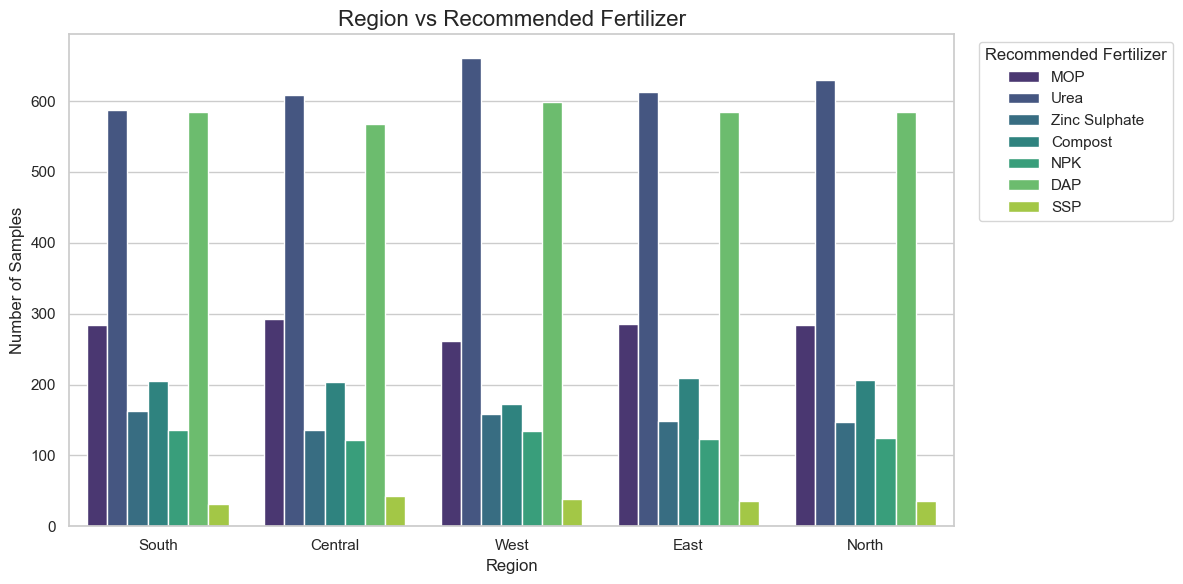

In [20]:
# Step 14.5 - Region vs Recommended Fertilizer

plt.figure(figsize=(12, 6))

sns.countplot(
    data=fertilizer_df,
    x="Region",
    hue="Recommended_Fertilizer",
    palette="viridis"
)

plt.title("Region vs Recommended Fertilizer", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Recommended Fertilizer", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

# Save the figure
plt.savefig(
    "../images/eda/fertilizer/region_vs_recommended_fertilizer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- Urea and DAP are the most frequently recommended fertilizers across all regions.
- The recommendation pattern is fairly consistent, indicating no significant regional variation.
- SSP is the least recommended fertilizer in every region.
- Overall, fertilizer recommendations appear to depend more on crop and soil characteristics than on geographical region.

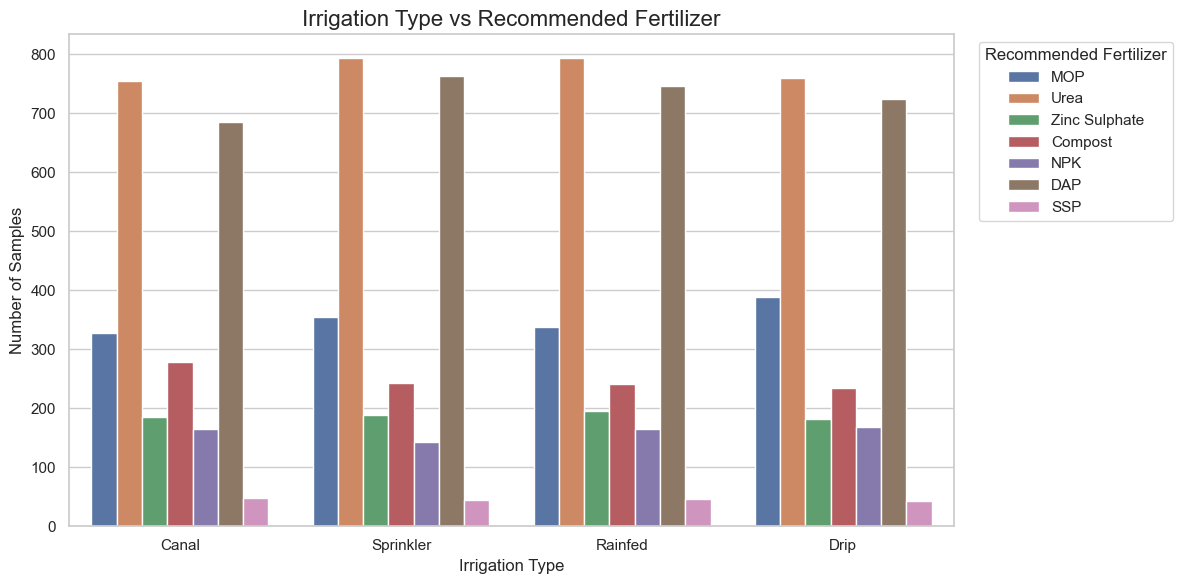

In [21]:
# Step 14.6 – Irrigation Type vs Recommended Fertilizer

plt.figure(figsize=(12, 6))

sns.countplot(
    data=fertilizer_df,
    x='Irrigation_Type',
    hue='Recommended_Fertilizer'
)

plt.title('Irrigation Type vs Recommended Fertilizer', fontsize=16)
plt.xlabel('Irrigation Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.legend(title='Recommended Fertilizer', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

# Save the plot
plt.savefig("../images/eda/fertilizer/irrigation_type_vs_recommended_fertilizer.png", dpi=300)

plt.show()

### 📌 Interpretation

- Urea and DAP are the most recommended fertilizers across all irrigation types.
- Fertilizer recommendation patterns remain fairly consistent for Canal, Sprinkler, Rainfed, and Drip irrigation.
- SSP is the least recommended fertilizer regardless of irrigation method.
- Overall, irrigation type has minimal influence on fertilizer recommendations compared to crop and soil characteristics.

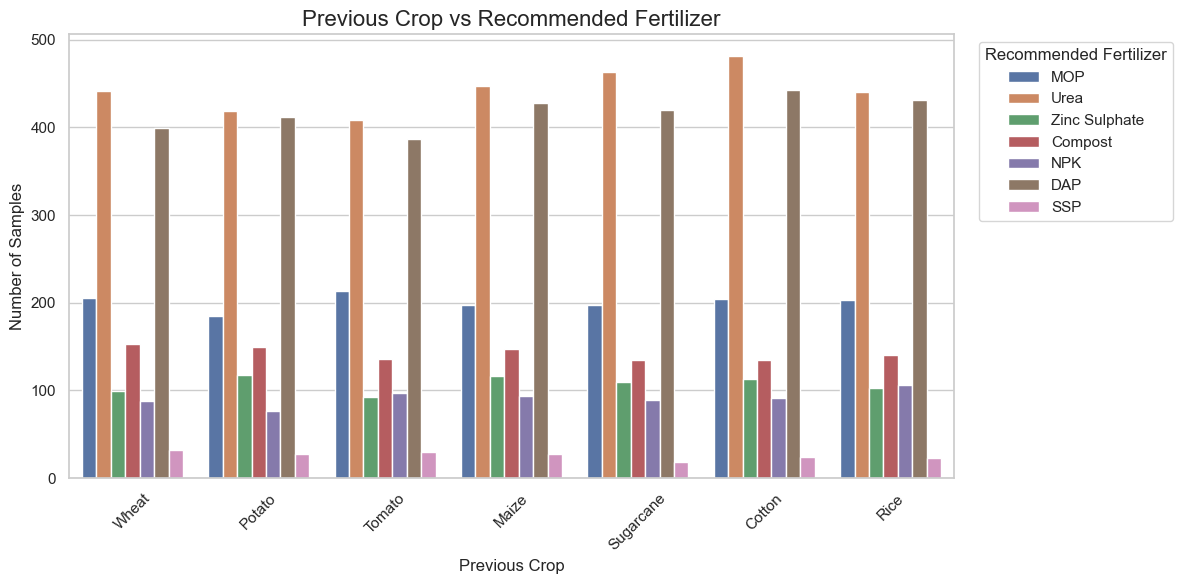

In [24]:
# Step 14.7 – Previous Crop vs Recommended Fertilizer

plt.figure(figsize=(12, 6))

sns.countplot(
    data=fertilizer_df,
    x='Previous_Crop',
    hue='Recommended_Fertilizer'
)

plt.title('Previous Crop vs Recommended Fertilizer', fontsize=16)
plt.xlabel('Previous Crop')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.legend(title='Recommended Fertilizer', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

# Save the plot
plt.savefig("../images/eda/fertilizer/previous_crop_vs_recommended_fertilizer.png", dpi=300)

plt.show()

### 📌 Interpretation

- Urea and DAP remain the most recommended fertilizers regardless of the previous crop.
- Fertilizer recommendation patterns are largely consistent across all previous crop types.
- SSP is the least recommended fertilizer for every previous crop.
- Overall, the previous crop has only a minor influence on fertilizer recommendations compared to soil and crop-specific factors.

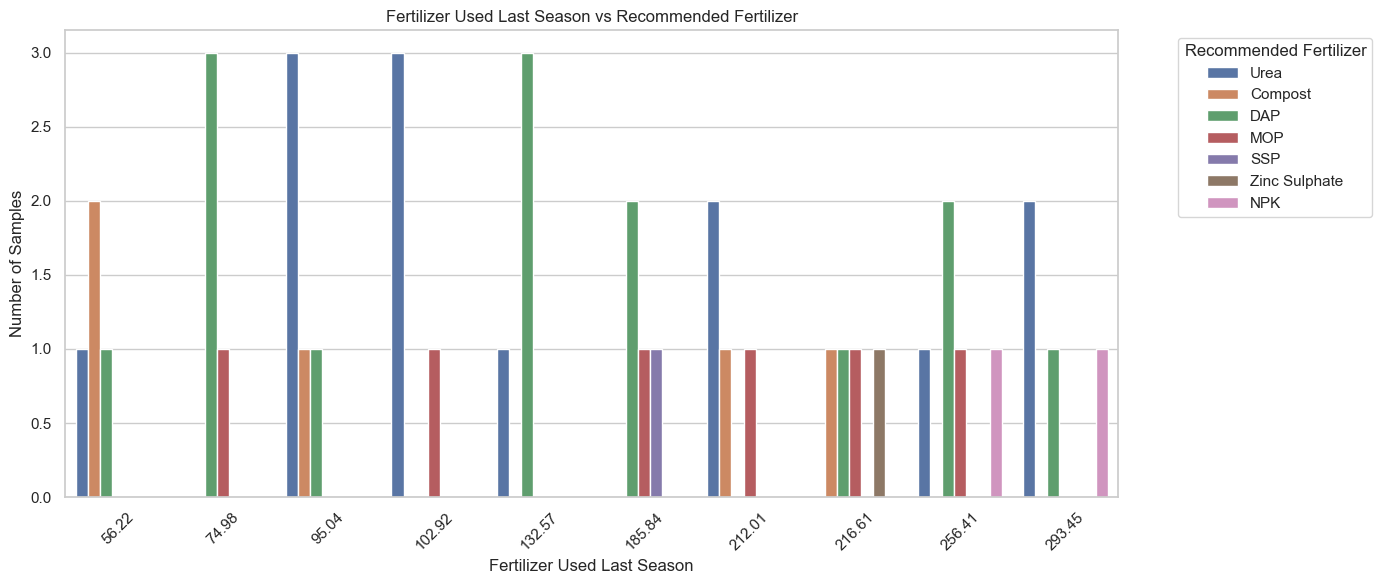

In [26]:
# Step 14.8 – Fertilizer Used Last Season vs Recommended Fertilizer

# Select Top 10 most frequently used fertilizers from last season
top_fertilizers = fertilizer_df["Fertilizer_Used_Last_Season"].value_counts().nlargest(10).index

filtered_df = fertilizer_df[
    fertilizer_df["Fertilizer_Used_Last_Season"].isin(top_fertilizers)
]

plt.figure(figsize=(14, 6))

sns.countplot(
    data=filtered_df,
    x="Fertilizer_Used_Last_Season",
    hue="Recommended_Fertilizer"
)

plt.title("Fertilizer Used Last Season vs Recommended Fertilizer")
plt.xlabel("Fertilizer Used Last Season")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.legend(title="Recommended Fertilizer", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    "../images/eda/fertilizer/fertilizer_used_last_season_vs_recommended_fertilizer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- The recommended fertilizer varies depending on the fertilizer used in the previous season.
- Urea and DAP remain the most frequently recommended fertilizers across most previous fertilizer types.
- This indicates that fertilizer recommendations are based on current soil and crop conditions rather than simply repeating the fertilizer used in the last season.
- The visualization highlights the importance of balanced nutrient management and crop-specific fertilizer planning.

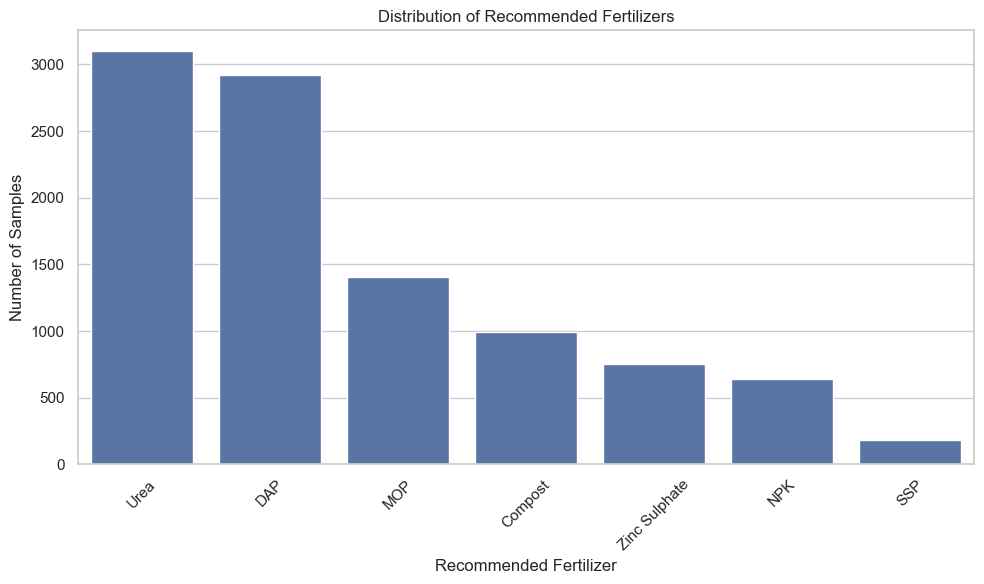

In [27]:
# Step 14.9 – Recommended Fertilizer Distribution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=fertilizer_df,
    x="Recommended_Fertilizer",
    order=fertilizer_df["Recommended_Fertilizer"].value_counts().index
)

plt.title("Distribution of Recommended Fertilizers")
plt.xlabel("Recommended Fertilizer")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../images/eda/fertilizer/recommended_fertilizer_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- The dataset contains multiple fertilizer recommendations with varying frequencies.
- Urea and DAP appear to be the most commonly recommended fertilizers, while SSP is recommended the least.
- The distribution indicates that some fertilizer classes are more prevalent than others.
- Understanding this class distribution is important before model training, as class imbalance can affect prediction performance.

# Step 15 – Numerical Feature Analysis

Analyze the distribution of all numerical soil and environmental features with respect to the recommended fertilizer. This analysis helps identify how soil properties, nutrient levels, and climatic conditions vary across different fertilizer recommendations and provides insights into the numerical features that are likely to influence the machine learning model.

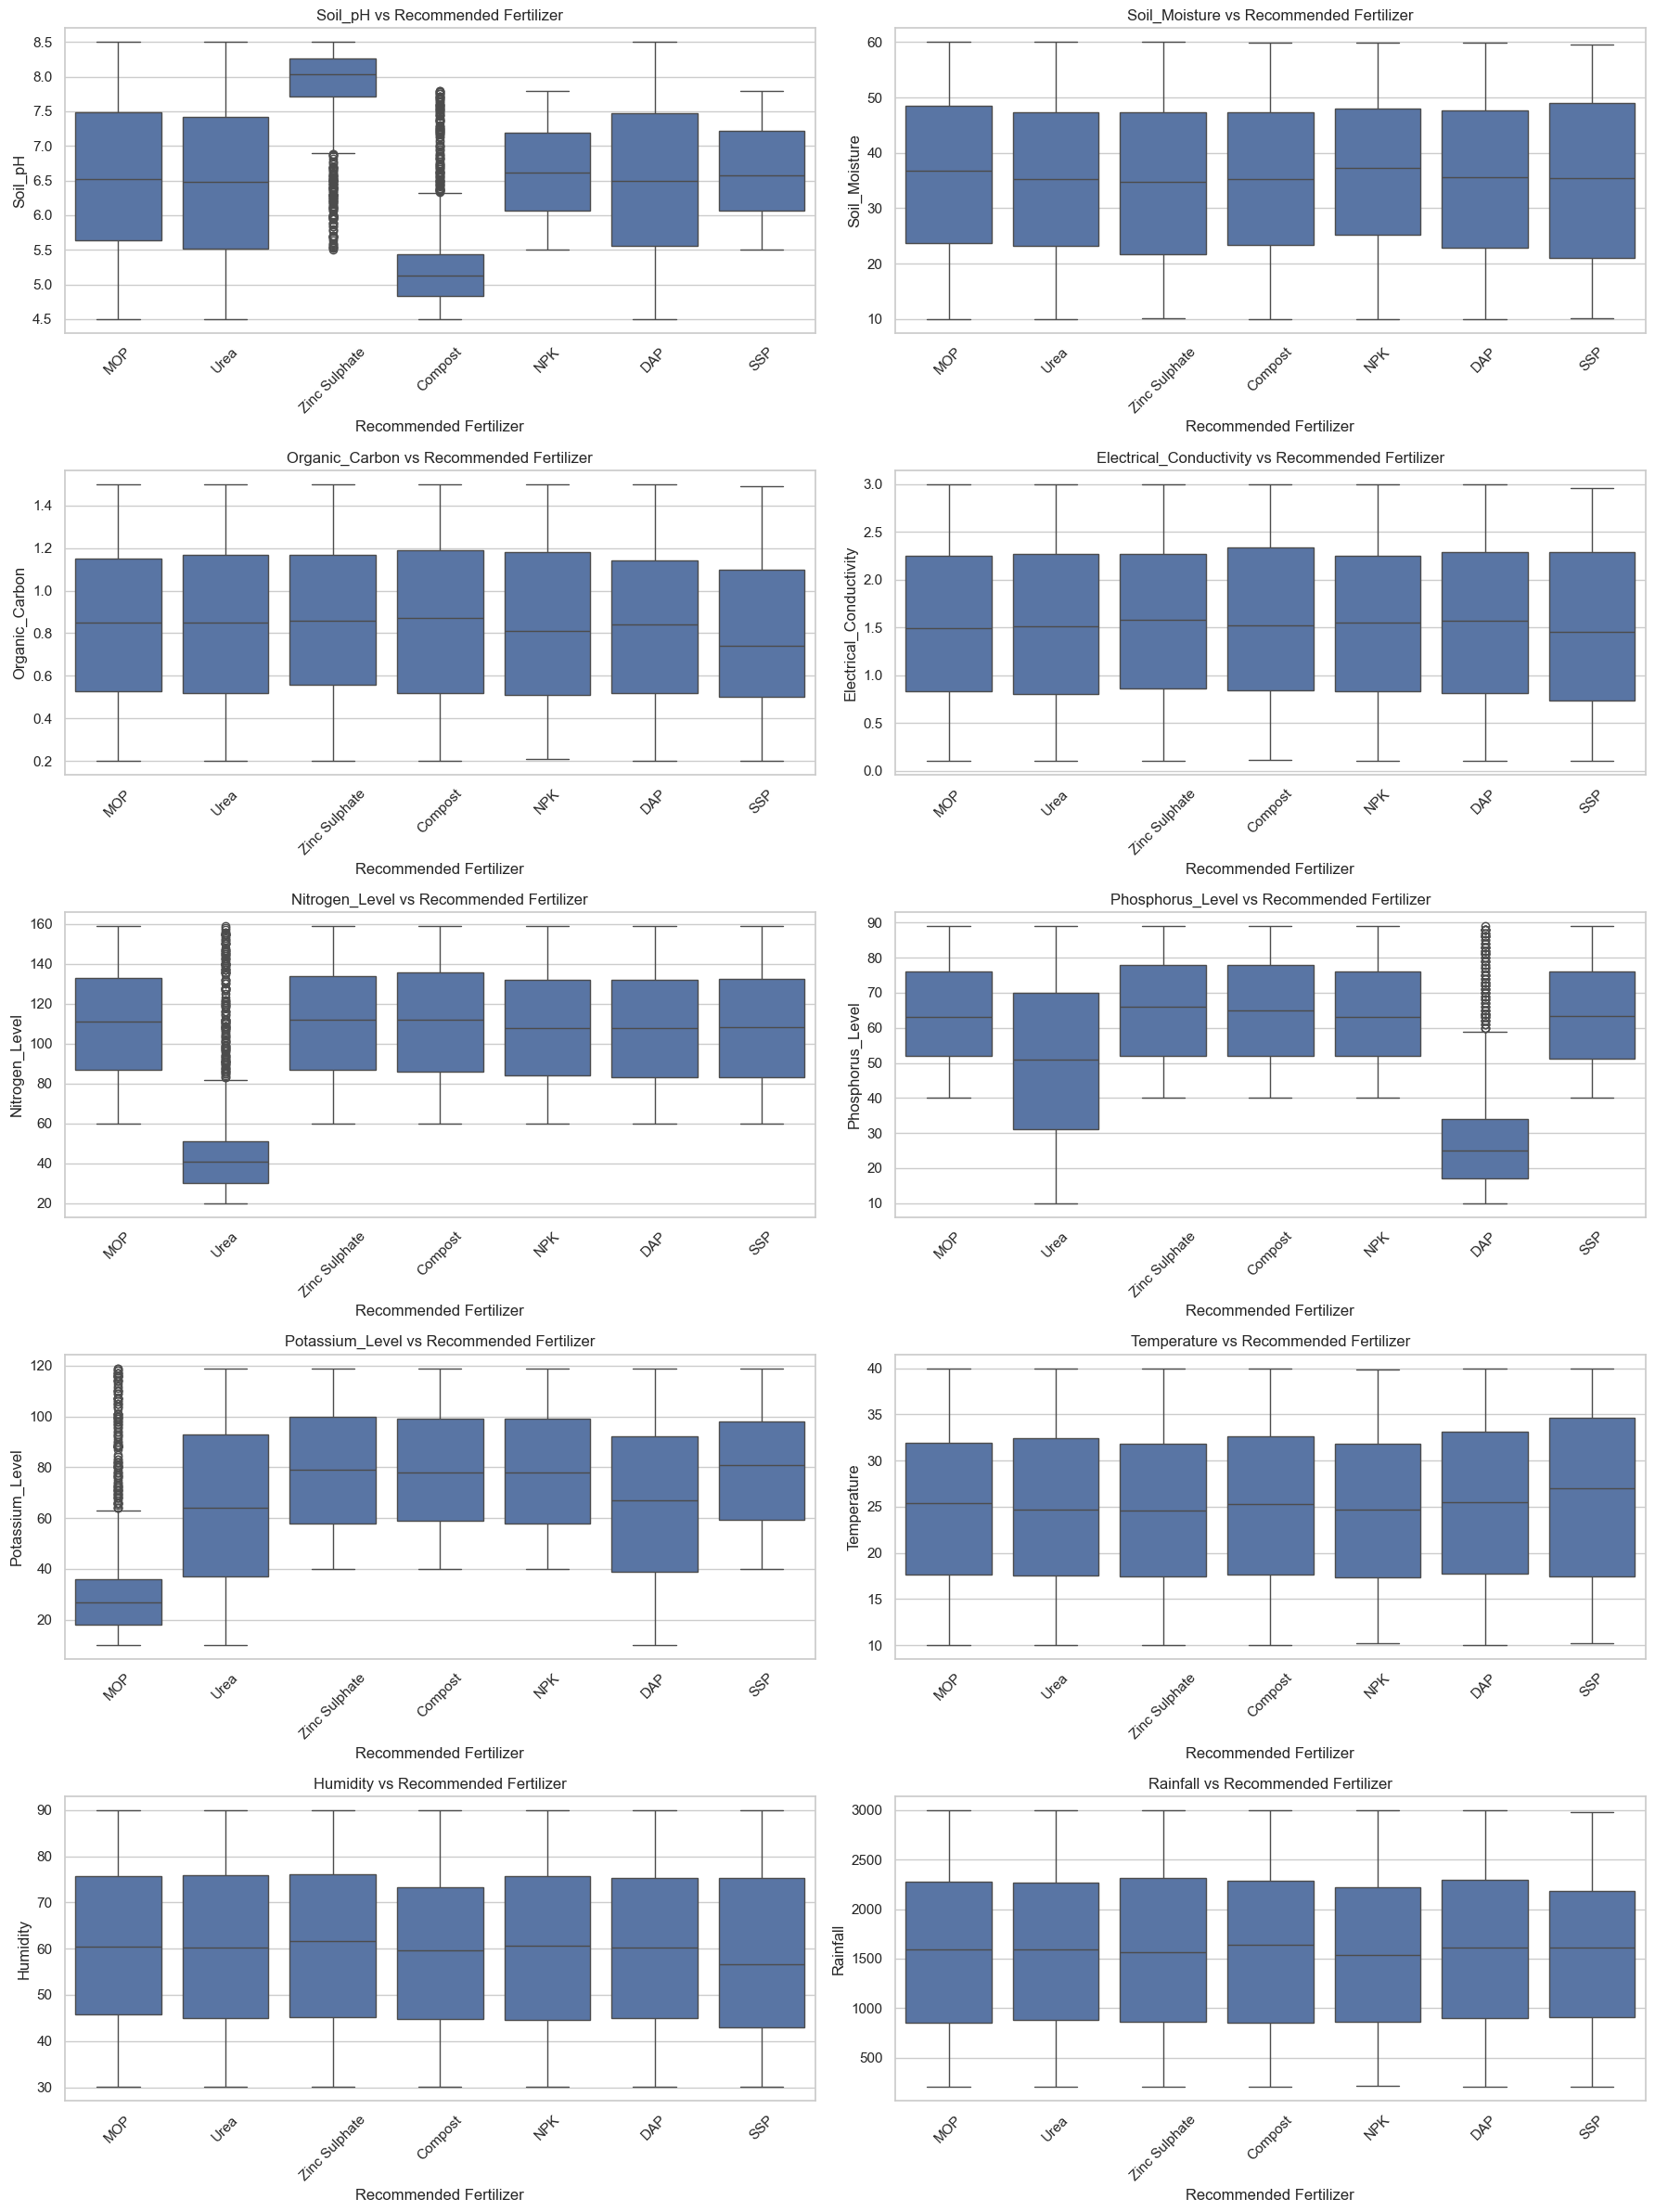

In [28]:
numerical_features = [
    "Soil_pH",
    "Soil_Moisture",
    "Organic_Carbon",
    "Electrical_Conductivity",
    "Nitrogen_Level",
    "Phosphorus_Level",
    "Potassium_Level",
    "Temperature",
    "Humidity",
    "Rainfall"
]

fig, axes = plt.subplots(5, 2, figsize=(18, 24))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        data=fertilizer_df,
        x="Recommended_Fertilizer",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} vs Recommended Fertilizer")
    axes[i].set_xlabel("Recommended Fertilizer")
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()

# Save figure
plt.savefig(
    "../images/eda/fertilizer/numerical_features_vs_recommended_fertilizer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 Interpretation

- The boxplots show the distribution of all numerical features across different recommended fertilizer classes.
- Soil pH, nutrient levels (Nitrogen, Phosphorus, and Potassium), and environmental factors such as Temperature, Humidity, and Rainfall exhibit noticeable variations among fertilizer recommendations.
- Several features contain outliers, indicating that fertilizer recommendations are made under a wide range of soil and climatic conditions.
- Differences in the median values and interquartile ranges suggest that numerical soil characteristics play an important role in determining the most suitable fertilizer.
- These observations indicate that the numerical features contain valuable predictive information and are expected to contribute significantly to the fertilizer recommendation model.

## Key Observations

### Crop Recommendation Dataset

- The dataset contains 2,200 samples with 7 numerical features and one target variable representing 22 crop classes.
- No missing values or inconsistent data types were observed.
- Most numerical features exhibit reasonable distributions with only a few outliers.
- Nutrient levels (N, P, and K), rainfall, humidity, and temperature show noticeable variation across different crop classes.
- The correlation analysis indicates that most features have low to moderate correlations, suggesting minimal multicollinearity.
- The target variable is perfectly balanced, with each crop class containing 100 samples, making the dataset well-suited for multi-class classification.

### Fertilizer Recommendation Dataset

- The dataset contains 10,000 samples comprising both numerical and categorical features.
- No missing values were detected, and the dataset is well structured for machine learning.
- Soil properties, nutrient levels, and environmental conditions vary considerably across fertilizer recommendations.
- Most categorical variables are fairly balanced, although the target variable shows moderate class imbalance, with Urea and DAP appearing more frequently than other fertilizers.
- Numerical feature distributions indicate the presence of some outliers but remain within realistic agricultural ranges.
- Correlation analysis shows no severe multicollinearity among numerical variables.
- Both numerical and categorical features demonstrate meaningful relationships with fertilizer recommendations, indicating their usefulness for predictive modeling.

### Overall Conclusion

The exploratory data analysis confirms that both datasets are clean, consistent, and suitable for machine learning. The identified feature distributions, correlations, and class characteristics provide valuable insights that will support effective model training and evaluation in the next phase of the project.